# Centrifugal Gas Compressor — Project Analysis with Python-Extended Simulation

---
## 0. User inputs — configure here before running

**This is the only cell that requires user configuration.**
All other cells read from these variables — do not modify parameters elsewhere.


In [1]:
# ═════════════════════════════════════════════════════════════════════════
# SECTION 0 — ALL USER INPUTS
# Run this cell first. All subsequent cells use these variables.
# ═════════════════════════════════════════════════════════════════════════

# ── Performance data ─────────────────────────────────────────────────────
CURVE_NAME   = "lp-sec1-caso-a"   # Petrobras/ccp curve identifier
EFF_CUTOFF   = 0.70               # Efficiency threshold for stonewall filter [-]
N_FIXED      = 9831.0             # Fixed-speed compressor reference [RPM]
SURGE_MARGIN = 0.10               # Anti-surge margin above surge flow [-]

# ── Suction conditions ───────────────────────────────────────────────────
P_SUC_BAR = 4.08    # Suction pressure [bar]
T_SUC_C   = 33.6    # Suction temperature [°C]

# ── Standard flow basis for production profile ───────────────────────────
# Production profile is defined in standard volumetric flow, not in actual suction flow.
# Sm³/h basis used in this notebook:
P_STD_BAR = 1.01325   # Standard pressure [bara]
T_STD_C   = 15.0      # Standard temperature [°C]

# Optional manual override:
# - None  -> auto-derived later from design point and EOS
# - float -> force a specific standard design flow directly here
Q_STD_DESIGN_SM3H = None   # Design flow rate at standard conditions [Sm³/h]

# ── Compressor Discharge Pressure ────────────────────────────────────────
# None  → pure antisurge model (classic VFD, no downstream pressure constraint)
# float → dual constraint model. From the discharge map, N≥8848 RPM covers
#          the full production range for r_p ≤ 3.55. Typical LP stage: 3.0–5.0.
#          Sensitivity to this parameter is studied in Section 7.
R_P_REQUIRED = 3.5   # ← set a float (e.g. 3.5) to activate pressure constraint

# ── Gas compositions (molar fractions) ───────────────────────────────────
# Year 1: design composition (Petrobras/ccp impeller_example)
# Ensure that gas composition sum is 1
COMPOSITION_YEAR_1 = {
    "methane":          0.58976,
    "ethane":           0.03099,
    "propane":          0.00600,
    "butane":           0.00080,
    "isobutane":        0.00050,
    "pentane":          0.00010,
    "isopentane":       0.00010,
    "nitrogen":         0.00550,
    "hydrogen sulfide": 0.00020,
    "CO2":              0.36605,
}
# Year 20: modelling assumption (replace with reservoir fluid study for real projects)
COMPOSITION_YEAR_20 = {
    "methane":          0.54000,
    "ethane":           0.02500,
    "propane":          0.00800,
    "butane":           0.00150,
    "isobutane":        0.00100,
    "pentane":          0.00020,
    "isopentane":       0.00020,
    "nitrogen":         0.00550,
    "hydrogen sulfide": 0.00020,
    "CO2":              0.41840,
}

# ── Gas production profile (relative shape only) ─────────────────────────
# Absolute production basis is Q_STD_DESIGN_SM3H.
# The parameters below only define the relative life-cycle shape.
PROJECT_LIFE  = 20
YRS_PLATEAU1  = 5
YRS_DECLINE1  = 5
LOAD_PLATEAU2 = 0.75
YRS_PLATEAU2  = 5
YRS_DECLINE2  = 5

# ── Degradation model ────────────────────────────────────────────────────
DECAY_RATE         = 0.015
OVERHAUL_INTERVAL  = 5
OVERHAUL_RECOVERY  = 0.45
DEGRADATION_FLOOR  = 0.85

# ── DWSIM paths (Section 6 validation only) ──────────────────────────────
DWSIM_PATH = r"C:\Users\<user>\AppData\Local\DWSIM" # Adjust your route
SIM_FILE   = r"C:\Users\<user>\Documents\gas_compressor\dwsim\Compressor_Validation.dwxmz" # Adjust your route

# ── Electricity & economics ──────────────────────────────────────────────
ELEC_PRICE_BASE = 0.08
ELEC_ESCALATION = 0.03
HOURS_PER_YEAR  = 8000
DISCOUNT_RATE   = 0.08
VFD_USD_KW      = 250.0
VFD_INSTALL_F   = 1.30

# ── Numerical settings ───────────────────────────────────────────────────
IRR_LOWER_BOUND       = 0.001
IRR_UPPER_BOUND       = 10.0
IRR_XTOL              = 1e-6
CROSS_TOL             = 1e-12
RP_SENSITIVITY_VALUES = [None, 2.5, 3.0, 3.5, 4.0, 4.56]
TIMER_REPEAT          = 1

# ── Validation ────────────────────────────────────────────────────────────
assert abs(sum(COMPOSITION_YEAR_1.values())  - 1.0) < 1e-6, "COMPOSITION_YEAR_1 must sum to 1"
assert abs(sum(COMPOSITION_YEAR_20.values()) - 1.0) < 1e-6, "COMPOSITION_YEAR_20 must sum to 1"
assert set(COMPOSITION_YEAR_1.keys()) == set(COMPOSITION_YEAR_20.keys()), "Compositions must have same components"
assert P_SUC_BAR > 0 and T_SUC_C > -273.15, "Invalid suction conditions"
assert P_STD_BAR > 0 and T_STD_C > -273.15, "Invalid standard conditions"
assert Q_STD_DESIGN_SM3H is None or Q_STD_DESIGN_SM3H > 0, "Q_STD_DESIGN_SM3H must be positive or None"

rp_str = str(R_P_REQUIRED) if R_P_REQUIRED is None else f"{R_P_REQUIRED:.2f}"
qstd_str = (
    "Auto-derived later from compressor curve"
    if Q_STD_DESIGN_SM3H is None
    else f"{Q_STD_DESIGN_SM3H:,.0f} Sm³/h"
)

print("═" * 60)
print("  SECTION 0 — User inputs loaded")
print("═" * 60)
print(f"  Curve              : {CURVE_NAME}")
print(f"  N_fixed            : {N_FIXED:.0f} RPM   |  Surge margin: {SURGE_MARGIN*100:.0f}%")
print(f"  P_suc / T_suc      : {P_SUC_BAR:.2f} bar / {T_SUC_C:.1f} °C")
print(f"  Standard basis     : {T_STD_C:.1f} °C / {P_STD_BAR:.5f} bara")
print(f"  Design flow rate   : {qstd_str}")
print(f"  R_P_REQUIRED       : {rp_str}")
print(f"  Project life       : {PROJECT_LIFE} years")
print(f"  Electricity        : {ELEC_PRICE_BASE:.3f} USD/kWh (+{ELEC_ESCALATION*100:.0f}%/yr)")
print(f"  Discount rate      : {DISCOUNT_RATE*100:.0f}%   |  VFD CAPEX: {VFD_USD_KW:.0f} USD/kW × {VFD_INSTALL_F:.2f}")
print(f"  DWSIM path set     : {'Yes' if '<your_user>' not in DWSIM_PATH else 'No (placeholder)'}")
print("═" * 60)


════════════════════════════════════════════════════════════
  SECTION 0 — User inputs loaded
════════════════════════════════════════════════════════════
  Curve              : lp-sec1-caso-a
  N_fixed            : 9831 RPM   |  Surge margin: 10%
  P_suc / T_suc      : 4.08 bar / 33.6 °C
  Standard basis     : 15.0 °C / 1.01325 bara
  Design flow rate   : Auto-derived later from compressor curve
  R_P_REQUIRED       : 3.50
  Project life       : 20 years
  Electricity        : 0.080 USD/kWh (+3%/yr)
  Discount rate      : 8%   |  VFD CAPEX: 250 USD/kW × 1.30
  DWSIM path set     : Yes
════════════════════════════════════════════════════════════


---
## 1. Imports and performance curve loading

Curves are loaded **directly from the Petrobras/ccp GitHub repository** — no manual
download required. The raw CSV files are fetched via `urllib` and parsed in memory.

The CSV format stores one speed per block, separated by a header line `x,<speed_rpm>`.
A **stonewall cutoff** (`eff_cutoff = 0.70`) removes the unstable choke region where
the cubic spline would otherwise oscillate. A **head monotonicity filter** removes points
where head increases with flow — physically impossible in stable operation.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.interpolate import CubicSpline, interp1d
from scipy.optimize import brentq
from pathlib import Path
from IPython.display import display
import urllib.request
import warnings
warnings.filterwarnings('ignore')
from matplotlib.lines import Line2D
from thermo import ChemicalConstantsPackage, PRMIX, CEOSLiquid, CEOSGas, FlashVL
from thermo.interaction_parameters import IPDB
import io, contextlib
import sys
import time

# ── Fetch curves directly from Petrobras/ccp GitHub ──────────────────────
_BASE_URL  = ("https://raw.githubusercontent.com/"
              "petrobras/ccp/main/ccp/tests/data/")
def _fetch_ccp_csv(curve_name: str, metric: str) -> str:
    """Fetch a ccp CSV file from GitHub and return its content as a string."""
    url = _BASE_URL + f"{curve_name}-{metric}.csv"
    with urllib.request.urlopen(url) as r:
        return r.read().decode("utf-8")


def load_performance_curves(curve_name: str, eff_cutoff: float = 0.70) -> dict:
    """
    Load head and efficiency curves for a compressor from Petrobras/ccp
    GitHub data.

    Filtering:
    - Efficiency curve: removes points with eff < eff_cutoff (stonewall filter)
    - Head curve: keeps only monotonically decreasing head branch
    """
    result = {}
    for metric in ("head", "eff"):
        text = _fetch_ccp_csv(curve_name, metric)
        lines = text.strip().splitlines()
        current_speed = None
        qs, vals = [], []

        for line in lines:
            parts = line.strip().split(",")
            if parts[0] == "x":
                if current_speed is not None:
                    if current_speed not in result:
                        result[current_speed] = {}
                    qs_arr   = np.array(qs)
                    vals_arr = np.array(vals)
                    if metric == "eff":
                        mask     = vals_arr >= eff_cutoff
                        qs_arr   = qs_arr[mask]
                        vals_arr = vals_arr[mask]
                    elif metric == "head":
                        keep = [0]
                        for i in range(1, len(vals_arr)):
                            if vals_arr[i] < vals_arr[keep[-1]]:
                                keep.append(i)
                        qs_arr   = qs_arr[keep]
                        vals_arr = vals_arr[keep]
                    result[current_speed][f"Q_{metric}"] = qs_arr
                    result[current_speed][metric]        = vals_arr
                current_speed = float(parts[1])
                qs, vals      = [], []
            else:
                qs.append(float(parts[0]))
                vals.append(float(parts[1]))

        if current_speed is not None:
            if current_speed not in result:
                result[current_speed] = {}
            qs_arr   = np.array(qs)
            vals_arr = np.array(vals)
            if metric == "eff":
                mask     = vals_arr >= eff_cutoff
                qs_arr   = qs_arr[mask]
                vals_arr = vals_arr[mask]
            elif metric == "head":
                keep = [0]
                for i in range(1, len(vals_arr)):
                    if vals_arr[i] < vals_arr[keep[-1]]:
                        keep.append(i)
                qs_arr   = qs_arr[keep]
                vals_arr = vals_arr[keep]
            result[current_speed][f"Q_{metric}"] = qs_arr
            result[current_speed][metric]        = vals_arr

    return result


def build_splines(curves: dict) -> dict:
    """
    Fit cubic splines to head and efficiency curves for each speed.
    Identifies key operating points: surge, BEP and stonewall limit.
    """
    splines = {}
    for N, data in sorted(curves.items()):
        Q_head   = data["Q_head"]
        Q_eff    = data["Q_eff"]
        cs_head  = CubicSpline(Q_head, data["head"], extrapolate=False)
        cs_eff   = CubicSpline(Q_eff,  data["eff"],  extrapolate=False)
        idx_bep  = np.argmax(data["eff"])
        splines[N] = {
            "cs_head":    cs_head,
            "cs_eff":     cs_eff,
            "Q_surge":    Q_head.min(),
            "Q_max":      Q_head.max(),
            "Q_bep":      Q_eff[idx_bep],
            "eff_bep":    data["eff"][idx_bep],
            "head_surge": float(cs_head(Q_head.min())),
        }
    return splines


print("Fetching performance curves from Petrobras/ccp GitHub...")
curves  = load_performance_curves(CURVE_NAME, eff_cutoff=EFF_CUTOFF)
splines = build_splines(curves)
SPEEDS  = sorted(splines.keys())

df_speed_lines = pd.DataFrame(
    [
        {
            "N_rpm": N,
            "Q_surge_m3h": s["Q_surge"],
            "Q_bep_m3h": s["Q_bep"],
            "Q_max_m3h": s["Q_max"],
            "eff_bep": s["eff_bep"],
            "head_surge_kJkg": s["head_surge"],
        }
        for N, s in sorted(splines.items())
    ]
)

print(f"Loaded {len(SPEEDS)} speed lines.")
display(
    df_speed_lines.round(
        {
            "N_rpm": 0,
            "Q_surge_m3h": 0,
            "Q_bep_m3h": 0,
            "Q_max_m3h": 0,
            "eff_bep": 4,
            "head_surge_kJkg": 1,
        }
    )
)

Fetching performance curves from Petrobras/ccp GitHub...
Loaded 5 speed lines.


,N_rpm,Q_surge_m3h,Q_bep_m3h,Q_max_m3h,eff_bep,head_surge_kJkg
0,6882.0,11219.0,11250.0,15219.0,0.7894,83.0
1,7865.0,13000.0,13708.0,18344.0,0.8118,111.7
2,8848.0,15000.0,16375.0,21500.0,0.8235,146.0
3,9831.0,18031.0,19250.0,24781.0,0.8306,181.1
4,10322.0,20125.0,21500.0,26469.0,0.8329,199.1


---
## 2. Performance map

The map shows the compressor operating envelope across all five speed lines.

- **Surge limit** (red dashed): left boundary of stable operation. Operating to the left
  causes destructive flow reversal
- **Anti-surge line** (orange dotted): 10% margin above surge — the control system
  opens the recycle valve if flow drops below this line (API 670 / Campbell TOTM)
- **BEP** (★): Best Efficiency Point at each speed
- **Surge zone** (red shading): forbidden operating region


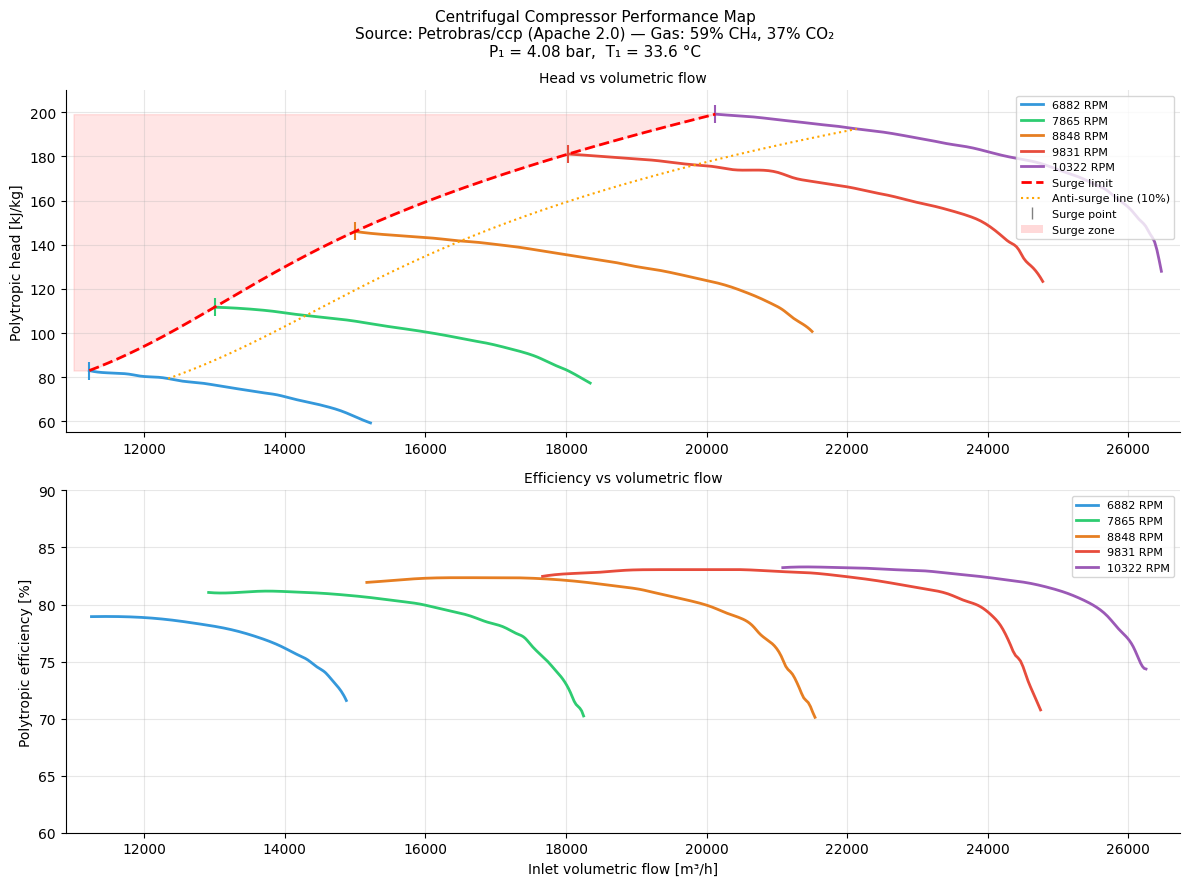

In [3]:
from matplotlib.lines import Line2D

COLORS = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=False)
fig.suptitle(
    'Centrifugal Compressor Performance Map\n'
    'Source: Petrobras/ccp (Apache 2.0) — Gas: 59% CH₄, 37% CO₂\n'
    'P₁ = 4.08 bar,  T₁ = 33.6 °C',
    fontsize=11, fontweight='normal'
)

for N, color in zip(SPEEDS, COLORS):
    s      = splines[N]
    Q_plot = np.linspace(s['Q_surge'], s['Q_max'], 200)

    ax1.plot(
        Q_plot, s['cs_head'](Q_plot),
        color=color, linewidth=2, label=f'{N:.0f} RPM'
    )
    ax1.scatter(
        s['Q_surge'], s['head_surge'],
        color=color, marker='|', s=150, zorder=5
    )

    Q_eff_plot = np.linspace(s['cs_eff'].x[0], s['cs_eff'].x[-1], 200)
    ax2.plot(
        Q_eff_plot, s['cs_eff'](Q_eff_plot) * 100,
        color=color, linewidth=2, label=f'{N:.0f} RPM'
    )

Q_surge_pts = [splines[N]['Q_surge'] for N in SPEEDS]
H_surge_pts = [splines[N]['head_surge'] for N in SPEEDS]
Q_asl_pts   = [splines[N]['Q_surge'] * (1 + SURGE_MARGIN) for N in SPEEDS]
H_asl_pts   = [
    float(splines[N]['cs_head'](splines[N]['Q_surge'] * (1 + SURGE_MARGIN)))
    for N in SPEEDS
]

cs_surge_Q = interp1d(SPEEDS, Q_surge_pts, kind='cubic')
cs_surge_H = interp1d(SPEEDS, H_surge_pts, kind='cubic')
cs_asl_Q   = interp1d(SPEEDS, Q_asl_pts, kind='cubic')
cs_asl_H   = interp1d(SPEEDS, H_asl_pts, kind='cubic')

N_fine       = np.linspace(min(SPEEDS), max(SPEEDS), 200)
Q_surge_fine = cs_surge_Q(N_fine)
H_surge_fine = cs_surge_H(N_fine)
Q_asl_fine   = cs_asl_Q(N_fine)
H_asl_fine   = cs_asl_H(N_fine)

ax1.plot(
    Q_surge_fine, H_surge_fine,
    color='red', linewidth=2, linestyle='--',
    label='Surge limit', zorder=6
)
ax1.plot(
    Q_asl_fine, H_asl_fine,
    color='orange', linewidth=1.5, linestyle=':',
    label=f'Anti-surge line ({SURGE_MARGIN*100:.0f}%)', zorder=6
)

Q_min_plot = min(s['Q_surge'] for s in splines.values()) * 0.98
ax1.fill_betweenx(
    H_surge_fine, Q_min_plot, Q_surge_fine,
    alpha=0.10, color='red', zorder=1
)

x_min = Q_min_plot * 0.99
x_max = max(s['Q_max'] for s in splines.values()) * 1.01

ax1.set_xlim(x_min, x_max)
ax1.set_ylim(55, 210)

legend_markers = [
    Line2D([0], [0], marker='|', color='gray', linestyle='None',
           markersize=8, label='Surge point'),
    plt.Rectangle((0, 0), 1, 1, fc='red', alpha=0.15, label='Surge zone'),
]

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles=handles + legend_markers,
    labels=labels + ['Surge point', 'Surge zone'],
    fontsize=8, loc='upper right'
)

ax1.set_ylabel('Polytropic head [kJ/kg]', fontsize=10)
ax1.set_title('Head vs volumetric flow', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

ax2.set_xlim(x_min, x_max)
ax2.set_ylim(60, 90)
ax2.set_xlabel('Inlet volumetric flow [m³/h]', fontsize=10)
ax2.set_ylabel('Polytropic efficiency [%]', fontsize=10)
ax2.set_title('Efficiency vs volumetric flow', fontsize=10)
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 3. Thermodynamic model — rigorous EOS method

We use **`thermo`** (Caleb Bell, MIT) with Peng-Robinson EOS and **ChemSep binary
interaction parameters** (BIPs) — a well-established, peer-reviewed source available
directly in `thermo`'s interaction parameter database, requiring no manual entry.
Agreement with DWSIM PR to within 0.04% on density confirms the BIP equivalence
a posteriori (Section 6); ChemSep BIPs were not chosen for consistency with DWSIM.

The gas composition matches the Petrobras/ccp `impeller_example` exactly.

### Two calculation methods

| Method | Z / k / ρ | Head correction | When to use |
|---|---|---|---|
| **`compute_operating_point`** (Lapina simplified) | Fixed at design | Lapina Eq.12 MW ratio | Years 1–7, fast sweeps |
| **`compute_operating_point_rigorous`** | Updated per composition | Lapina Eq.12 + real ρ | Years 8–20, validation |

The error of the simplified method is quantified in Section 5.


In [4]:
# ── Design gas composition — derived from Section 0 inputs ───────────────
COMPONENTS   = list(COMPOSITION_YEAR_1.keys())
Z_GAS_DESIGN = list(COMPOSITION_YEAR_1.values())

P_SUC_PA     = P_SUC_BAR * 1e5
T_SUC_K      = T_SUC_C + 273.15

consts, props = ChemicalConstantsPackage.from_IDs(COMPONENTS)
kijs      = IPDB.get_ip_asymmetric_matrix('ChemSep PR', consts.CASs, 'kij')
eos_kw    = dict(Tcs=consts.Tcs, Pcs=consts.Pcs, omegas=consts.omegas, kijs=kijs)
liq_eos   = CEOSLiquid(PRMIX, HeatCapacityGases=props.HeatCapacityGases, eos_kwargs=eos_kw)
gas_eos   = CEOSGas(PRMIX,  HeatCapacityGases=props.HeatCapacityGases, eos_kwargs=eos_kw)
flasher   = FlashVL(consts, props, liquid=liq_eos, gas=gas_eos)

suc_design = flasher.flash(T=T_SUC_K, P=P_SUC_PA, zs=Z_GAS_DESIGN)
MW_DESIGN  = sum(Z_GAS_DESIGN[i]*consts.MWs[i] for i in range(len(COMPONENTS)))
Z_DESIGN   = suc_design.gas.Z()
K_DESIGN   = suc_design.gas.Cp() / suc_design.gas.Cv()
RHO_DESIGN = suc_design.gas.rho_mass()
H1_DESIGN  = suc_design.gas.H()

df_design_state = pd.DataFrame(
    [
        {
            "T_suc_C": T_SUC_C,
            "T_suc_K": T_SUC_K,
            "P_suc_bar": P_SUC_BAR,
            "MW_mix_gmol": MW_DESIGN,
            "Z": Z_DESIGN,
            "k_CpCv": K_DESIGN,
            "rho_kgm3": RHO_DESIGN,
        }
    ]
)

print("Design suction state (year 1)")
display(
    df_design_state.round(
        {
            "T_suc_C": 1,
            "T_suc_K": 2,
            "P_suc_bar": 2,
            "MW_mix_gmol": 3,
            "Z": 4,
            "k_CpCv": 4,
            "rho_kgm3": 4,
        }
    )
)

Design suction state (year 1)


,T_suc_C,T_suc_K,P_suc_bar,MW_mix_gmol,Z,k_CpCv,rho_kgm3
0,33.6,306.75,4.08,27.018,0.9878,1.3008,4.3755


In [5]:
def _get_head_eff(Q_m3h: float, N_rpm: float):
    """
    Read polytropic head [kJ/kg] and efficiency [-] from splines.
    Interpolates between bracketing speed curves using fan laws if needed.
    Raises ValueError if (Q, N) is outside the operating envelope.
    """
    speeds       = sorted(splines.keys())
    N_min, N_max = speeds[0], speeds[-1]
    if not (N_min <= N_rpm <= N_max):
        raise ValueError(f"N={N_rpm} out of range [{N_min},{N_max}]")

    if N_rpm in splines:
        s = splines[N_rpm]
        if not (s['Q_surge'] <= Q_m3h <= s['Q_max']):
            raise ValueError(
                f"Q={Q_m3h:.0f} out of range [{s['Q_surge']:.0f},{s['Q_max']:.0f}]")
        return float(s['cs_head'](Q_m3h)), float(s['cs_eff'](Q_m3h))

    N_lo  = max(n for n in speeds if n <= N_rpm)
    N_hi  = min(n for n in speeds if n >= N_rpm)
    alpha = (N_rpm - N_lo) / (N_hi - N_lo)
    s_lo, s_hi = splines[N_lo], splines[N_hi]
    phi   = Q_m3h / N_rpm
    Q_lo  = np.clip(phi*N_lo, s_lo['Q_surge'], s_lo['Q_max'])
    Q_hi  = np.clip(phi*N_hi, s_hi['Q_surge'], s_hi['Q_max'])
    Q_surge = (1-alpha)*s_lo['Q_surge'] + alpha*s_hi['Q_surge']
    Q_max   = (1-alpha)*s_lo['Q_max']   + alpha*s_hi['Q_max']
    if not (Q_surge <= Q_m3h <= Q_max):
        raise ValueError(f"Q={Q_m3h:.0f} out of interpolated range")
    head = ((1-alpha)*float(s_lo['cs_head'](Q_lo))*(N_rpm/N_lo)**2
            + alpha  *float(s_hi['cs_head'](Q_hi))*(N_rpm/N_hi)**2)
    eta  = ((1-alpha)*float(s_lo['cs_eff'](Q_lo))
            + alpha  *float(s_hi['cs_eff'](Q_hi)))
    return head, eta


def _discharge_state(W_poly_Jkg, eta_poly, h1_Jmol, MW_kgmol,
                     Z_ref, k_ref, z_gas):
    """Estimate discharge T and P from polytropic work and enthalpy."""
    h2_Jmol     = h1_Jmol + (W_poly_Jkg / eta_poly) * MW_kgmol
    n_poly      = (k_ref*eta_poly) / (k_ref*eta_poly - (k_ref-1))
    r_p_est     = (1 + W_poly_Jkg*(n_poly-1) /
                   (n_poly*Z_ref*8.314/MW_kgmol*T_SUC_K))**(n_poly/(n_poly-1))
    P_disch_est = P_SUC_PA * r_p_est
    try:
        disch       = flasher.flash(H=h2_Jmol, P=P_disch_est, zs=z_gas)
        return disch.T - 273.15, P_disch_est/1e5
    except Exception:
        return T_SUC_K*r_p_est**((n_poly-1)/n_poly) - 273.15, P_disch_est/1e5


def compute_operating_point(Q_m3h: float, N_rpm: float,
                             eta_factor: float = 1.0,
                             MW_override: float = None) -> dict:
    """
    Lapina (1982) simplified method.

    Uses design-condition Z, k, rho. Applies Lapina Eq.12 MW correction
    to head. Fast — suitable for annual sweeps (years 1–7).

    Parameters
    ----------
    Q_m3h       : volumetric flow at suction [m\u00b3/h]
    N_rpm       : rotational speed [rpm]
    eta_factor  : efficiency multiplier (1.0 = design, <1.0 = degraded)
    MW_override : if set, apply Lapina MW correction using this MW [g/mol]
    """
    try:
        head_kJkg, eta_poly = _get_head_eff(Q_m3h, N_rpm)
    except ValueError as e:
        return {"is_valid": False, "reason": str(e)}

    eta_poly *= eta_factor
    MW_use    = MW_override if MW_override is not None else MW_DESIGN
    if MW_override is not None:
        head_kJkg *= MW_use / MW_DESIGN

    W_poly   = head_kJkg * 1000.0
    m_dot    = (Q_m3h/3600.0) * RHO_DESIGN
    power_kW = m_dot * W_poly / eta_poly / 1000.0

    T_disch_C, P_disch_bar = _discharge_state(
        W_poly, eta_poly, H1_DESIGN, MW_DESIGN/1000.0,
        Z_DESIGN, K_DESIGN, Z_GAS_DESIGN)

    return {
        "is_valid": True, "Q_m3h": Q_m3h, "N_rpm": N_rpm,
        "head_kJkg": head_kJkg, "eta_poly": eta_poly,
        "power_kW": power_kW, "m_dot_kgs": m_dot,
        "P_disch_bar": P_disch_bar, "T_disch_C": T_disch_C,
        "r_pressure": P_disch_bar/P_SUC_BAR,
    }


def compute_operating_point_rigorous(Q_m3h: float, N_rpm: float,
                                      z_gas: list,
                                      eta_factor: float = 1.0) -> dict:
    """
    Rigorous EOS method — full composition flash each call.

    Recomputes Z, k, rho, h1 from actual z_gas composition.
    More accurate for years 8–20 when gas MW has drifted (~5.6%).
    Use when accuracy better than 2% is required.

    Parameters
    ----------
    Q_m3h      : volumetric flow at suction [m\u00b3/h]
    N_rpm      : rotational speed [rpm]
    z_gas      : mole fraction list for actual gas composition
    eta_factor : efficiency multiplier
    """
    try:
        head_kJkg, eta_poly = _get_head_eff(Q_m3h, N_rpm)
    except ValueError as e:
        return {"is_valid": False, "reason": str(e)}

    eta_poly  *= eta_factor
    suc_real   = flasher.flash(T=T_SUC_K, P=P_SUC_PA, zs=z_gas)
    MW_real    = sum(z_gas[i]*consts.MWs[i] for i in range(len(COMPONENTS)))
    Z_real     = suc_real.gas.Z()
    k_real     = suc_real.gas.Cp() / suc_real.gas.Cv()
    rho_real   = suc_real.gas.rho_mass()
    h1_real    = suc_real.gas.H()

    head_kJkg *= MW_real / MW_DESIGN   # Lapina Eq.12 with real MW
    W_poly     = head_kJkg * 1000.0
    m_dot      = (Q_m3h/3600.0) * rho_real
    power_kW   = m_dot * W_poly / eta_poly / 1000.0

    T_disch_C, P_disch_bar = _discharge_state(
        W_poly, eta_poly, h1_real, MW_real/1000.0,
        Z_real, k_real, z_gas)

    return {
        "is_valid": True, "Q_m3h": Q_m3h, "N_rpm": N_rpm,
        "MW_real": MW_real, "Z_real": Z_real, "k_real": k_real,
        "rho_real": rho_real, "head_kJkg": head_kJkg,
        "eta_poly": eta_poly, "power_kW": power_kW,
        "m_dot_kgs": m_dot, "P_disch_bar": P_disch_bar,
        "T_disch_C": T_disch_C, "r_pressure": P_disch_bar/P_SUC_BAR,
    }


# Validation at BEP for each speed

print("Validation at BEP for each speed")
# Validation at BEP for each speed
rows = []
for N in SPEEDS:
    r = compute_operating_point(splines[N]['Q_bep'], N)
    if r['is_valid']:
        rows.append({
            "N [RPM]": N,
            "Q_bep [m³/h]": r["Q_m3h"],
            "Head [kJ/kg]": r["head_kJkg"],
            "Eff [-]": r["eta_poly"],
            "Power [kW]": r["power_kW"],
            "P_disch [bar]": r["P_disch_bar"],
            "T_disch [°C]": r["T_disch_C"],
            "r_p = P2/P1 [-]": r["r_pressure"],
        })

df_bep_validation = pd.DataFrame(rows)

if not df_bep_validation.empty:
    df_bep_validation["N [RPM]"] = df_bep_validation["N [RPM]"].round(0).astype(int)
    df_bep_validation["Q_bep [m³/h]"] = df_bep_validation["Q_bep [m³/h]"].round(0).astype(int)
    df_bep_validation["Head [kJ/kg]"] = df_bep_validation["Head [kJ/kg]"].round(1)
    df_bep_validation["Eff [-]"] = df_bep_validation["Eff [-]"].round(3)
    df_bep_validation["Power [kW]"] = df_bep_validation["Power [kW]"].round(1)
    df_bep_validation["P_disch [bar]"] = df_bep_validation["P_disch [bar]"].round(3)
    df_bep_validation["T_disch [°C]"] = df_bep_validation["T_disch [°C]"].round(1)
    df_bep_validation["r_p = P2/P1 [-]"] = df_bep_validation["r_p = P2/P1 [-]"].round(3)

df_bep_validation

Validation at BEP for each speed


,N [RPM],Q_bep [m³/h],Head [kJ/kg],Eff [-],Power [kW],P_disch [bar],T_disch [°C],r_p = P2/P1 [-]
0,6882,11250,82.8,0.789,1433.9,8.982,107.3,2.202
1,7865,13708,110.3,0.812,2263.6,11.308,127.9,2.771
2,8848,16375,142.1,0.824,3433.4,14.505,151.7,3.555
3,9831,19250,178.2,0.831,5020.5,18.892,178.3,4.630
4,10322,21500,194.9,0.833,6113.1,21.204,190.2,5.197


---
## 4. Anti-surge control — fixed speed vs VFD

### Anti-surge logic

When process demand falls below `Q_antisurge = Q_surge × 1.10`, the recycle valve
opens. The compressor always processes `Q_total = Q_process + Q_recycle`.
The recycled fraction exists solely to protect the compressor from surge —
mechanically necessary, but thermodynamically **pure waste**.

### Strategy comparison

| Strategy | Control | Advantage | Disadvantage |
|---|---|---|---|
| **A — Fixed speed + recycle** | Constant N, open recycle when needed | Simple, low CAPEX | High energy waste at low load |
| **B — VFD** | Reduce N to match demand | Minimal recycle | Higher CAPEX |

`compare_strategies` finds the minimum VFD speed at which `Q_antisurge(N) = Q_process`,
eliminating recycle while respecting the surge margin.


In [6]:
# Sentinel to distinguish:
# - "use global R_P_REQUIRED"  -> default behavior
# - "explicitly disable pressure constraint" -> r_p_req=None
_RP_USE_GLOBAL = object()

# Caches used to speed up repeated Section 4 / Section 7 evaluations
_ANTISURGE_EVAL_CACHE = {}
_MODEL_CACHE_TAG = (
    CURVE_NAME,
    round(float(EFF_CUTOFF), 8),
    round(float(SURGE_MARGIN), 8),
    round(float(P_SUC_BAR), 8),
    round(float(T_SUC_C), 8),
)


def _resolve_r_p_req(r_p_req):
    """Resolve sentinel/default behavior for pressure-ratio constraint."""
    return R_P_REQUIRED if r_p_req is _RP_USE_GLOBAL else r_p_req


def _z_cache_key(z_gas):
    """Hashable cache key for gas composition."""
    if z_gas is None:
        return None
    return tuple(round(float(zi), 10) for zi in z_gas)


def _get_surge_flow(N_rpm: float) -> float:
    """Interpolate Q_surge at any speed within the operating range."""
    speeds = sorted(splines.keys())
    if N_rpm in splines:
        return splines[N_rpm]['Q_surge']
    N_lo  = max(n for n in speeds if n <= N_rpm)
    N_hi  = min(n for n in speeds if n >= N_rpm)
    alpha = (N_rpm - N_lo) / (N_hi - N_lo)
    return (1 - alpha) * splines[N_lo]['Q_surge'] + alpha * splines[N_hi]['Q_surge']


# Precompute surge interpolation once — reused in compare_strategies()
_Q_SURGE_POINTS = np.array([splines[N]['Q_surge'] for N in SPEEDS], dtype=float)
_CS_QSURGE_N    = interp1d(SPEEDS, _Q_SURGE_POINTS, kind='cubic')
_Q_ASMIN        = float(_CS_QSURGE_N(SPEEDS[0]))  * (1 + SURGE_MARGIN)
_Q_ASMAX        = float(_CS_QSURGE_N(SPEEDS[-1])) * (1 + SURGE_MARGIN)


def _apply_antisurge(Q_process: float, N_rpm: float, compute_fn, **kwargs) -> dict:
    """Apply anti-surge recycle logic using any compute function."""
    Q_surge     = _get_surge_flow(N_rpm)
    Q_antisurge = Q_surge * (1 + SURGE_MARGIN)
    Q_recycle   = max(0.0, Q_antisurge - Q_process)
    Q_total     = Q_process + Q_recycle

    pto = compute_fn(Q_total, N_rpm, **kwargs)
    if not pto['is_valid']:
        return {"is_valid": False, "reason": pto.get("reason")}

    frac_rec = Q_recycle / Q_total if Q_total > 0 else 0.0
    return {
        "is_valid": True,
        "Q_process": Q_process,
        "Q_recycle": Q_recycle,
        "Q_total": Q_total,
        "power_kW": pto['power_kW'],
        "power_recycle_kW": pto['power_kW'] * frac_rec,
        "P_disch_bar": pto['P_disch_bar'],
        "T_disch_C": pto['T_disch_C'],
        "eta_poly": pto['eta_poly'],
    }


def compute_antisurge_fixed(Q_process, N_rpm, eta_factor=1.0, MW_override=None):
    """Anti-surge operation using Lapina simplified method."""
    return _apply_antisurge(
        Q_process, N_rpm, compute_operating_point,
        eta_factor=eta_factor, MW_override=MW_override
    )


def compute_antisurge_rigorous(Q_process, N_rpm, z_gas, eta_factor=1.0):
    """Anti-surge operation using rigorous EOS method."""
    return _apply_antisurge(
        Q_process, N_rpm, compute_operating_point_rigorous,
        z_gas=z_gas, eta_factor=eta_factor
    )


def _cached_antisurge_eval(Q_process: float, N_rpm: float,
                           eta_factor: float = 1.0,
                           MW_override: float = None,
                           z_gas: list = None) -> dict:
    """
    Cache anti-surge operating points because the same evaluations are reused
    repeatedly in Section 7 base case, sensitivity, and timer profiling.
    """
    key = (
        _MODEL_CACHE_TAG,
        round(float(Q_process), 6),
        round(float(N_rpm), 6),
        round(float(eta_factor), 8),
        None if MW_override is None else round(float(MW_override), 8),
        _z_cache_key(z_gas),
    )
    if key not in _ANTISURGE_EVAL_CACHE:
        result = (
            compute_antisurge_rigorous(Q_process, N_rpm, z_gas=z_gas, eta_factor=eta_factor)
            if z_gas is not None else
            compute_antisurge_fixed(Q_process, N_rpm, eta_factor=eta_factor, MW_override=MW_override)
        )
        _ANTISURGE_EVAL_CACHE[key] = dict(result)
    return dict(_ANTISURGE_EVAL_CACHE[key])


def compare_strategies(Q_process: float, N_fixed: float = N_FIXED,
                       eta_factor: float = 1.0,
                       MW_override: float = None,
                       z_gas: list = None,
                       r_p_req=_RP_USE_GLOBAL) -> dict:
    """
    Compare Strategy A (fixed speed + recycle) vs Strategy B (VFD).

    r_p_req behavior:
      - default (_RP_USE_GLOBAL): use global R_P_REQUIRED from Section 0
      - None                    : pure antisurge model (no pressure constraint)
      - float                   : explicit pressure-ratio requirement
    """
    _r_p = _resolve_r_p_req(r_p_req)
    p_disch_required = P_SUC_BAR * _r_p if _r_p is not None else None

    # ── Strategy A: fixed speed ───────────────────────────────────────────
    A = _cached_antisurge_eval(
        Q_process, N_fixed, eta_factor=eta_factor,
        MW_override=MW_override, z_gas=z_gas
    )
    if not A['is_valid']:
        return {"is_valid": False}

    # ── Strategy B: VFD — Constraint 1: anti-surge ───────────────────────
    if Q_process <= _Q_ASMIN:
        N_antisurge = SPEEDS[0]
    elif Q_process >= _Q_ASMAX:
        N_antisurge = SPEEDS[-1]
    else:
        N_antisurge = brentq(
            lambda N: float(_CS_QSURGE_N(N)) * (1 + SURGE_MARGIN) - Q_process,
            SPEEDS[0], SPEEDS[-1], xtol=1.0
        )

    # ── Strategy B: VFD — Constraint 2: discharge pressure ───────────────
    if _r_p is None:
        N_vfd = N_antisurge
        N_pressure = N_antisurge
        constraint = "antisurge"
    else:
        _local_p_cache = {}

        def _p_disch(N_try):
            key = round(float(N_try), 6)
            if key not in _local_p_cache:
                r = _cached_antisurge_eval(
                    Q_process, N_try, eta_factor=eta_factor,
                    MW_override=MW_override, z_gas=z_gas
                )
                if r['is_valid'] and r['P_disch_bar'] is not None:
                    v = float(r['P_disch_bar'])
                    _local_p_cache[key] = v if np.isfinite(v) else 0.0
                else:
                    _local_p_cache[key] = 0.0
            return _local_p_cache[key]

        p_at_Nfixed = _p_disch(N_fixed)
        p_at_Nmin   = _p_disch(SPEEDS[0])

        if p_at_Nfixed < p_disch_required:
            N_pressure = N_fixed
            constraint = "N_max+recycle"
        elif p_at_Nmin >= p_disch_required:
            N_pressure = SPEEDS[0]
            constraint = "antisurge"
        elif p_at_Nfixed <= p_at_Nmin or not np.isfinite(p_at_Nfixed - p_at_Nmin):
            N_pressure = N_fixed
            constraint = "pressure"
        else:
            try:
                N_pressure = brentq(
                    lambda N: _p_disch(N) - p_disch_required,
                    SPEEDS[0], N_fixed, xtol=1.0
                )
                constraint = "pressure" if N_pressure > N_antisurge else "antisurge"
            except Exception:
                N_pressure = N_fixed
                constraint = "pressure"

        N_vfd = min(max(N_antisurge, N_pressure), N_fixed)
        if constraint != "N_max+recycle":
            constraint = "pressure" if N_pressure > N_antisurge else "antisurge"

    B = _cached_antisurge_eval(
        Q_process, N_vfd, eta_factor=eta_factor,
        MW_override=MW_override, z_gas=z_gas
    )
    if not B['is_valid']:
        return {"is_valid": False}

    saving_kW = A['power_kW'] - B['power_kW']
    return {
        "is_valid": True,
        "Q_process": Q_process,

        "A_N_rpm": N_fixed,
        "A_power_kW": A['power_kW'],
        "A_recycle_kW": A['power_recycle_kW'],
        "A_Q_recycle": A['Q_recycle'],
        "A_Q_total": A['Q_total'],
        "A_P_disch": A['P_disch_bar'],
        "A_T_disch_C": A['T_disch_C'],
        "A_eta_poly": A['eta_poly'],

        "B_N_rpm": N_vfd,
        "B_power_kW": B['power_kW'],
        "B_recycle_kW": B['power_recycle_kW'],
        "B_Q_recycle": B['Q_recycle'],
        "B_Q_total": B['Q_total'],
        "B_P_disch": B['P_disch_bar'],
        "B_T_disch_C": B['T_disch_C'],
        "B_eta_poly": B['eta_poly'],

        "saving_kW": saving_kW,
        "saving_pct": saving_kW / A['power_kW'] * 100 if A['power_kW'] > 0 else np.nan,
        "constraint": constraint,
        "N_antisurge": N_antisurge,
        "N_pressure": N_pressure,
        "P_disch_required": p_disch_required,
    }


# ── Design point + downstream pressure requirement ────────────────────────
Q_design = splines[N_FIXED]['Q_bep']
P_DISCH_REQUIRED = P_SUC_BAR * R_P_REQUIRED if R_P_REQUIRED is not None else None

# ── Physical turndown limit ───────────────────────────────────────────────
_Q_antisurge_Nmin = _get_surge_flow(SPEEDS[0]) * (1 + SURGE_MARGIN)
LOAD_MIN_PHYSICAL = _Q_antisurge_Nmin / Q_design

df_control_summary = pd.DataFrame(
    [
        {"parameter": "Design Q_bep", "value": Q_design, "unit": "m³/h"},
        {"parameter": "N_fixed", "value": N_FIXED, "unit": "RPM"},
        {"parameter": "Surge margin", "value": SURGE_MARGIN * 100, "unit": "%"},
        {"parameter": "Q_antisurge @ N_min", "value": _Q_antisurge_Nmin, "unit": "m³/h"},
        {"parameter": "Physical LOAD_MIN", "value": LOAD_MIN_PHYSICAL, "unit": "-"},
        {"parameter": "R_P_REQUIRED", "value": str(R_P_REQUIRED), "unit": "-"},
        {"parameter": "P_DISCH_REQUIRED", "value": P_DISCH_REQUIRED if P_DISCH_REQUIRED is not None else np.nan, "unit": "bar"},
    ]
)

Q_range = np.linspace(_Q_antisurge_Nmin, Q_design, 8)
results = [
    r for Q in Q_range
    for r in [compare_strategies(Q, N_fixed=N_FIXED)]
    if r['is_valid']
]
df_comp = pd.DataFrame(results)

df_comp_display = df_comp[
    [
        "Q_process",
        "A_power_kW",
        "A_Q_recycle",
        "A_P_disch",
        "B_N_rpm",
        "B_power_kW",
        "B_Q_recycle",
        "B_P_disch",
        "saving_pct",
        "constraint",
    ]
].rename(
    columns={
        "Q_process": "Q_process_m3h",
        "A_power_kW": "Fixed_kW",
        "A_Q_recycle": "Fixed_recycle_m3h",
        "A_P_disch": "Fixed_P_disch_bar",
        "B_N_rpm": "VFD_N_rpm",
        "B_power_kW": "VFD_kW",
        "B_Q_recycle": "VFD_recycle_m3h",
        "B_P_disch": "VFD_P_disch_bar",
        "saving_pct": "saving_pct",
        "constraint": "constraint",
    }
)

print("Section 4 summary")
display(df_control_summary.round({"value": 3}))
display(
    df_comp_display.round(
        {
            "Q_process_m3h": 0,
            "Fixed_kW": 1,
            "Fixed_recycle_m3h": 0,
            "Fixed_P_disch_bar": 2,
            "VFD_N_rpm": 1,
            "VFD_kW": 1,
            "VFD_recycle_m3h": 0,
            "VFD_P_disch_bar": 2,
            "saving_pct": 1,
        }
    )
)


Section 4 summary


,parameter,value,unit
0,Design Q_bep,19250.0,m³/h
1,N_fixed,9831.0,RPM
2,Surge margin,10.0,%
3,Q_antisurge @ N_min,12340.57,m³/h
4,Physical LOAD_MIN,0.641069,-
5,R_P_REQUIRED,3.5,-
6,P_DISCH_REQUIRED,14.28,bar


,Q_process_m3h,Fixed_kW,Fixed_recycle_m3h,Fixed_P_disch_bar,VFD_N_rpm,VFD_kW,VFD_recycle_m3h,VFD_P_disch_bar,saving_pct,constraint
0,12341.0,5112.1,7494.0,18.62,8803.5,3391.4,4060.0,14.28,33.7,pressure
1,13328.0,5112.1,6507.0,18.62,8803.5,3391.4,3073.0,14.28,33.7,pressure
2,14315.0,5112.1,5520.0,18.62,8803.2,3391.1,2085.0,14.28,33.7,pressure
3,15302.0,5112.1,4533.0,18.62,8803.5,3391.5,1099.0,14.28,33.7,pressure
4,16289.0,5112.1,3546.0,18.62,8803.5,3391.5,112.0,14.28,33.7,pressure
5,17276.0,5112.1,2558.0,18.62,9119.4,3864.9,145.0,15.47,24.4,antisurge
6,18263.0,5112.1,1571.0,18.62,9421.9,4365.0,184.0,16.71,14.6,antisurge
7,19250.0,5112.1,584.0,18.62,9687.6,4836.5,98.0,17.89,5.4,antisurge


### Interpreting the results

The table above shows the sweep from minimum process flow (Q_antisurge at N_min) to
design flow (Q_bep at N_FIXED). Key observations:

- **Fixed speed power** is constant regardless of Q_process — the compressor always
  operates at the same N_FIXED. Energy not needed for the process is wasted as recycle.
- **Recycle** grows as Q_process decreases — at minimum flow, the fixed-speed
  compressor recirculates a large fraction of its throughput solely to avoid surge.
- **VFD N** decreases with Q_process — the drive reduces speed to match demand,
  eliminating recycle and reducing shaft power.
- **Save%** represents the energy saving of VFD vs fixed speed at each flow point.
  With `R_P_REQUIRED = None` (pure antisurge model), saving grows monotonically as
  flow decreases. Setting `R_P_REQUIRED` to a finite value activates the downstream
  pressure constraint and reduces this saving during decline — studied in Section 7.


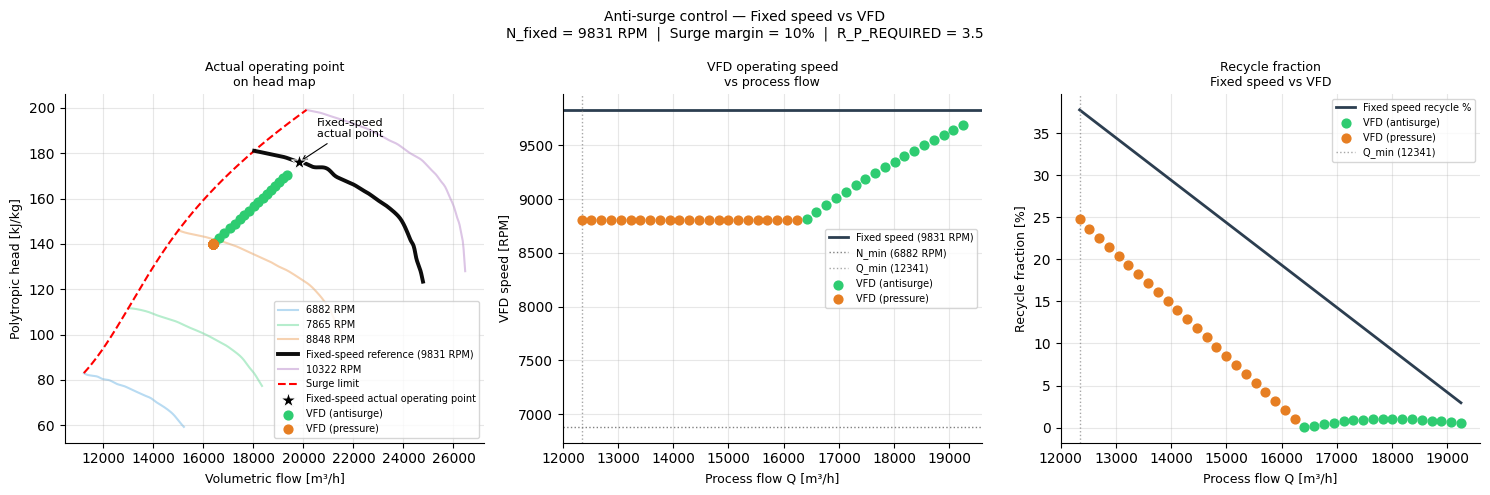

In [7]:
CONSTRAINT_COLORS = {
    'antisurge':     '#2ecc71',
    'pressure':      '#e67e22',
    'N_max+recycle': '#e74c3c',
}

Q_sweep = np.linspace(_Q_antisurge_Nmin, Q_design, 40)

rows_sw = []
for Q in Q_sweep:
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        r = compare_strategies(Q, N_fixed=N_FIXED)
    if r['is_valid']:
        rows_sw.append({
            'Q_process':   Q,
            'N_vfd':       r['B_N_rpm'],
            'Q_recycle_A': r['A_Q_recycle'],
            'Q_recycle_B': r['B_Q_recycle'],
            'Q_total_A':   Q + r['A_Q_recycle'],
            'Q_total_B':   Q + r['B_Q_recycle'],
            'frac_rec_A':  r['A_Q_recycle'] / (Q + r['A_Q_recycle']) * 100,
            'frac_rec_B':  r['B_Q_recycle'] / (Q + r['B_Q_recycle']) * 100,
            'saving_pct':  r['saving_pct'],
            'constraint':  r['constraint'],
        })

df_sw = pd.DataFrame(rows_sw)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Anti-surge control \u2014 Fixed speed vs VFD\n'
    f'N_fixed = {N_FIXED:.0f} RPM  |  Surge margin = {SURGE_MARGIN*100:.0f}%  |  '
    f'R_P_REQUIRED = {str(R_P_REQUIRED)}',
    fontsize=10, fontweight='normal'
)

# ── Panel 1: Actual operating point on head map ───────────────────────────
ax = axes[0]

# Speed lines: highlight N_FIXED curve clearly
for N, color in zip(SPEEDS, COLORS):
    s = splines[N]
    Q_p = np.linspace(s['Q_surge'], s['Q_max'], 200)

    is_fixed_ref = np.isclose(N, N_FIXED)

    ax.plot(
        Q_p,
        s['cs_head'](Q_p),
        color=('black' if is_fixed_ref else color),
        linewidth=(2.8 if is_fixed_ref else 1.5),
        alpha=(0.95 if is_fixed_ref else 0.35),
        zorder=(6 if is_fixed_ref else 1),
        label=(f'Fixed-speed reference ({N:.0f} RPM)' if is_fixed_ref else f'{N:.0f} RPM')
    )

# Surge limit
ax.plot(
    cs_surge_Q(N_fine),
    cs_surge_H(N_fine),
    color='red',
    linewidth=1.5,
    linestyle='--',
    label='Surge limit',
    zorder=5
)

# Fixed-speed actual operating point:
# this is essentially a single point because Q_total_A stays constant
Q_fixed_actual = float(df_sw['Q_total_A'].iloc[0])

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    r_fixed = compute_operating_point(Q_fixed_actual, N_FIXED)

H_fixed_actual = r_fixed['head_kJkg'] if r_fixed['is_valid'] else np.nan

ax.scatter(
    [Q_fixed_actual],
    [H_fixed_actual],
    color='black',
    edgecolor='white',
    linewidth=0.8,
    s=140,
    marker='*',
    zorder=10,
    label='Fixed-speed actual operating point'
)

ax.annotate(
    'Fixed-speed\nactual point',
    xy=(Q_fixed_actual, H_fixed_actual),
    xytext=(Q_fixed_actual + 700, H_fixed_actual + 10),
    fontsize=8,
    ha='left',
    va='bottom',
    arrowprops=dict(arrowstyle='->', lw=0.8, color='black')
)

# VFD: actual Q_total on N_vfd curve
H_B, Q_B = [], []
for _, row in df_sw.iterrows():
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        r = compute_operating_point(row['Q_total_B'], row['N_vfd'])
    H_B.append(r['head_kJkg'] if r['is_valid'] else np.nan)
    Q_B.append(row['Q_total_B'])

for constraint, c_color in CONSTRAINT_COLORS.items():
    mask = df_sw['constraint'] == constraint
    if mask.any():
        ax.scatter(
            [Q_B[i] for i in df_sw.index[mask]],
            [H_B[i] for i in df_sw.index[mask]],
            color=c_color,
            s=40,
            zorder=9,
            label=f'VFD ({constraint})'
        )

ax.set_xlabel('Volumetric flow [m³/h]', fontsize=9)
ax.set_ylabel('Polytropic head [kJ/kg]', fontsize=9)
ax.set_title('Actual operating point\non head map', fontsize=9)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2: VFD speed vs Q_process ──────────────────────────────────────
ax = axes[1]
ax.axhline(N_FIXED, color='#2c3e50', linewidth=2, linestyle='-',
           label=f'Fixed speed ({N_FIXED:.0f} RPM)')
ax.axhline(SPEEDS[0], color='gray', linewidth=1, linestyle=':',
           label=f'N_min ({SPEEDS[0]:.0f} RPM)')
ax.axvline(_Q_antisurge_Nmin, color='gray', linewidth=1, linestyle=':',
           alpha=0.7, label=f'Q_min ({_Q_antisurge_Nmin:.0f})')

for constraint, c_color in CONSTRAINT_COLORS.items():
    mask = df_sw['constraint'] == constraint
    if mask.any():
        ax.scatter(df_sw.loc[mask,'Q_process'], df_sw.loc[mask,'N_vfd'],
                   color=c_color, s=40, zorder=5, label=f'VFD ({constraint})')

ax.set_xlabel('Process flow Q [m\u00b3/h]', fontsize=9)
ax.set_ylabel('VFD speed [RPM]', fontsize=9)
ax.set_title('VFD operating speed\nvs process flow', fontsize=9)
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# ── Panel 3: Recycle fraction vs Q_process ────────────────────────────────
ax = axes[2]
ax.plot(df_sw['Q_process'], df_sw['frac_rec_A'], color='#2c3e50',
        linewidth=2, label='Fixed speed recycle %')

for constraint, c_color in CONSTRAINT_COLORS.items():
    mask = df_sw['constraint'] == constraint
    if mask.any():
        ax.scatter(df_sw.loc[mask,'Q_process'], df_sw.loc[mask,'frac_rec_B'],
                   color=c_color, s=40, zorder=5, label=f'VFD ({constraint})')

ax.axvline(_Q_antisurge_Nmin, color='gray', linewidth=1, linestyle=':',
           alpha=0.7, label=f'Q_min ({_Q_antisurge_Nmin:.0f})')
ax.set_xlabel('Process flow Q [m\u00b3/h]', fontsize=9)
ax.set_ylabel('Recycle fraction [%]', fontsize=9)
ax.set_title('Recycle fraction\nFixed speed vs VFD', fontsize=9)
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()


---
## 5. Production profile, gas composition evolution & performance degradation

### Production profile

The 20-year field profile is now defined on a **standard-flow basis**:
**Sm³/h at 15 °C and 1.01325 bara**.

This keeps the production profile tied to a field/reporting quantity, while the
compressor calculations still use the **actual inlet volumetric flow at suction
conditions**, derived year by year from the standard flow and the evolving gas
composition.

A 20-year field life is modelled in four phases:
1. **Plateau 1** (years 1–5): maximum throughput at design standard flow
2. **Decline 1** (years 6–10): exponential decline as reservoir pressure drops
3. **Plateau 2** (years 11–15): stabilised production at 75% of design standard flow
4. **Decline 2** (years 16–20): further exponential decline to the physical turndown limit

**Physical turndown limit (`LOAD_MIN`):** the minimum process flow is still imposed by
the anti-surge limit at minimum compressor speed, but it is now converted to a
**standard-flow equivalent** before being used in the production profile. This keeps
the profile physically consistent with the compressor map while expressing production
in Sm³/h.

Operating below this flow requires recycle regardless of strategy.
This is a physical constraint of the compressor, not a modelling choice.

### Gas composition evolution — coupled to cumulative production

Composition change is driven by how much gas has been produced, not by calendar time.
During plateau phases (high production rate), MW drifts faster.
During decline phases (low production rate), MW drifts slowly.

`COMPOSITION_YEAR_20` is a modelling assumption: methane depletes ~8% relative,
CO₂ concentrates proportionally, giving +5.6% MW over 20 years — conservative for
LP gas. Replace with reservoir fluid study data for real projects.

### Performance degradation model

Polytropic efficiency follows an **exponential decay** within each overhaul interval —
degradation is faster early (small clearance changes have larger relative impact) and
slows as the machine reaches a worn-in state.

At each major overhaul (every 5 years), **45% of the efficiency lost** since the last
overhaul is recovered. Permanent degradation accumulates — the machine never returns
to its original condition.

Parameter values (`DECAY_RATE`, `OVERHAUL_RECOVERY`) are modelling choices consistent
with field data for well-maintained centrifugal compressors on clean gas.
Adjust to match your equipment and service history.

### Lapina (1982) vs rigorous EOS

When MW increases due to field depletion, three suction properties are affected.
Z and k vary negligibly (<0.1%); density increases +5.6% over 20 years.
The Lapina simplified method uses fixed design-condition density — it underestimates
power progressively as the field depletes. The crossover year (>2% error) is
quantified in the table below.


In [8]:
# ── Production profile basis: Sm³/h at standard conditions ──────────────────
P_STD_PA = P_STD_BAR * 1e5
T_STD_K   = T_STD_C + 273.15


def _state_Z(T_K: float, P_Pa: float, z_gas: list) -> float:
    """Compressibility factor for a given state and composition."""
    state = flasher.flash(T=T_K, P=P_Pa, zs=z_gas)
    return float(state.gas.Z())


def q_std_from_suction(Q_suc_m3h: float, z_gas: list) -> float:
    """Convert actual inlet flow at suction conditions to standard flow [Sm³/h]."""
    Z_suc = _state_Z(T_SUC_K, P_SUC_PA, z_gas)
    Z_std = _state_Z(T_STD_K, P_STD_PA, z_gas)
    return float(Q_suc_m3h * (Z_std / Z_suc) * (T_STD_K / T_SUC_K) * (P_SUC_PA / P_STD_PA))


def q_suction_from_std(Q_std_Sm3h: float, z_gas: list) -> float:
    """Convert standard flow [Sm³/h] to actual inlet flow at suction conditions."""
    Z_suc = _state_Z(T_SUC_K, P_SUC_PA, z_gas)
    Z_std = _state_Z(T_STD_K, P_STD_PA, z_gas)
    return float(Q_std_Sm3h * (Z_suc / Z_std) * (T_SUC_K / T_STD_K) * (P_STD_PA / P_SUC_PA))


def _annual_load_from_min(year: int, load_min: float) -> float:
    """Fractional production load (0-1) in project year `year` on a standard-flow basis."""
    if year <= YRS_PLATEAU1:
        return 1.00
    elif year <= YRS_PLATEAU1 + YRS_DECLINE1:
        t = year - YRS_PLATEAU1
        k = -np.log(LOAD_PLATEAU2 / 1.00) / YRS_DECLINE1
        return float(np.exp(-k * t))
    elif year <= YRS_PLATEAU1 + YRS_DECLINE1 + YRS_PLATEAU2:
        return float(LOAD_PLATEAU2)
    else:
        t = year - (YRS_PLATEAU1 + YRS_DECLINE1 + YRS_PLATEAU2)
        k = -np.log(load_min / LOAD_PLATEAU2) / YRS_DECLINE2
        return float(LOAD_PLATEAU2 * np.exp(-k * t))


def _annual_composition_from_profile(year: int, cum_prod: np.ndarray, total_prod: float) -> list:
    """Gas composition interpolated by cumulative produced gas fraction."""
    if len(cum_prod) == 1 or total_prod <= cum_prod[0]:
        alpha = 0.0
    else:
        alpha = (cum_prod[year - 1] - cum_prod[0]) / (total_prod - cum_prod[0])
        alpha = float(min(max(alpha, 0.0), 1.0))

    z = [
        COMPOSITION_YEAR_1[c] + alpha * (COMPOSITION_YEAR_20[c] - COMPOSITION_YEAR_1[c])
        for c in COMPONENTS
    ]
    z_sum = sum(z)
    return [zi / z_sum for zi in z]


if Q_STD_DESIGN_SM3H is None:
    Q_STD_DESIGN = q_std_from_suction(Q_design, Z_GAS_DESIGN)
else:
    Q_STD_DESIGN = float(Q_STD_DESIGN_SM3H)
Q_STD_DESIGN_SM3H = float(Q_STD_DESIGN)


# Iteratively convert the physical turndown limit from actual suction flow to
# its standard-flow equivalent at late-field composition.
_load_min_guess = float(LOAD_MIN_PHYSICAL)
for _ in range(6):
    _load_profile_guess = np.array(
        [_annual_load_from_min(y, _load_min_guess) for y in range(1, PROJECT_LIFE + 1)],
        dtype=float,
    )
    _cum_prod_guess = np.cumsum(_load_profile_guess)
    _cum_prod_total_guess = float(_cum_prod_guess[-1])

    _z_end = _annual_composition_from_profile(PROJECT_LIFE, _cum_prod_guess, _cum_prod_total_guess)
    _Q_std_min = q_std_from_suction(_Q_antisurge_Nmin, _z_end)
    _new_guess = float(_Q_std_min / Q_STD_DESIGN)

    if abs(_new_guess - _load_min_guess) < 1e-6:
        _load_min_guess = _new_guess
        break
    _load_min_guess = _new_guess

LOAD_MIN = round(_load_min_guess, 4)   # standard-flow equivalent of physical turndown

_load_profile   = np.array([_annual_load_from_min(y, LOAD_MIN) for y in range(1, PROJECT_LIFE + 1)], dtype=float)
_cum_prod       = np.cumsum(_load_profile)
_cum_prod_total = float(_cum_prod[-1])


def annual_load(year: int) -> float:
    """Fractional production load (0-1) relative to design standard flow [Sm³/h]."""
    return float(_load_profile[year - 1])


def annual_composition(year: int) -> list:
    """Gas composition interpolated by cumulative production fraction."""
    return _annual_composition_from_profile(year, _cum_prod, _cum_prod_total)


def annual_standard_flow(year: int) -> float:
    """Standard gas flow [Sm³/h] in project year `year`."""
    return float(annual_load(year) * Q_STD_DESIGN)


def annual_suction_flow(year: int, z_gas: list = None) -> float:
    """Actual inlet volumetric flow at suction conditions [m³/h]."""
    z_use = annual_composition(year) if z_gas is None else z_gas
    return q_suction_from_std(annual_standard_flow(year), z_use)


def annual_eta_factor(year: int,
                      decay_rate=DECAY_RATE,
                      recovery_frac=OVERHAUL_RECOVERY) -> float:
    interval = OVERHAUL_INTERVAL
    years_into = (year - 1) % interval
    oh_completed = (year - 1) // interval

    eta_start = 1.0  # post-overhaul maximum for first interval

    for _ in range(oh_completed):
        eta_end = eta_start * np.exp(-decay_rate * interval)

        # Recover only a fraction of the loss accumulated during this interval
        eta_start = eta_end + recovery_frac * (eta_start - eta_end)

    eta_y = eta_start * np.exp(-decay_rate * years_into)
    return max(eta_y, DEGRADATION_FLOOR)


def annual_elec_price(year: int) -> float:
    """Escalating electricity price [USD/kWh]."""
    return ELEC_PRICE_BASE * (1 + ELEC_ESCALATION) ** (year - 1)


years         = np.arange(1, PROJECT_LIFE + 1)
loads         = np.array([annual_load(y) for y in years], dtype=float)          # fraction of design standard flow
Q_std_profile = np.array([annual_standard_flow(y) for y in years], dtype=float)
Q_suc_profile = np.array([annual_suction_flow(y) for y in years], dtype=float)
eta_factors   = np.array([annual_eta_factor(y) for y in years], dtype=float)
elec_prices   = np.array([annual_elec_price(y) for y in years], dtype=float)

annual_profile_summary = pd.DataFrame([
    {"Parameter": "Q_design @ suction",        "Value": round(Q_design, 0),           "Units": "m³/h"},
    {"Parameter": "Q_design @ standard",       "Value": round(Q_STD_DESIGN, 0),       "Units": "Sm³/h"},
    {"Parameter": "LOAD_MIN (physical, suction basis)", "Value": round(LOAD_MIN_PHYSICAL * 100, 1), "Units": "% of Q_design"},
    {"Parameter": "LOAD_MIN (standard-flow basis)",     "Value": round(LOAD_MIN * 100, 1),          "Units": "% of Q_STD_DESIGN"},
    {"Parameter": "Standard pressure",         "Value": P_STD_BAR,                    "Units": "bara"},
    {"Parameter": "Standard temperature",      "Value": T_STD_C,                      "Units": "°C"},
    {"Parameter": "DECAY_RATE",                "Value": round(DECAY_RATE, 4),         "Units": "1/yr"},
    {"Parameter": "OVERHAUL_INTERVAL",         "Value": OVERHAUL_INTERVAL,            "Units": "yr"},
    {"Parameter": "OVERHAUL_RECOVERY",         "Value": f"{OVERHAUL_RECOVERY*100:.0f}","Units": "% of interval loss"},
    {"Parameter": "DEGRADATION_FLOOR",         "Value": round(DEGRADATION_FLOOR, 2),  "Units": "-"},
    {"Parameter": "Electricity year 1",        "Value": round(elec_prices[0], 4),     "Units": "USD/kWh"},
    {"Parameter": f"Electricity year {PROJECT_LIFE}", "Value": round(elec_prices[-1], 4), "Units": "USD/kWh"},
])

print("=== study values ===")
annual_profile_summary

=== study values ===


,Parameter,Value,Units
0,Q_design @ suction,19250.0,m³/h
1,Q_design @ standard,73439.0,Sm³/h
2,"LOAD_MIN (physical, suction basis)",64.1,% of Q_design
3,LOAD_MIN (standard-flow basis),64.1,% of Q_STD_DESIGN
4,Standard pressure,1.01325,bara
5,Standard temperature,15.0,°C
6,DECAY_RATE,0.015,1/yr
7,OVERHAUL_INTERVAL,5,yr
8,OVERHAUL_RECOVERY,45,% of interval loss
9,DEGRADATION_FLOOR,0.85,-


In [9]:
_SECTION5_OPERATING_CACHE = {}


def _copy_operating_profile_result(result: dict) -> dict:
    """Return a safe copy of the cached operating-profile result."""
    copied = {}
    for key, value in result.items():
        copied[key] = value.copy(deep=True) if isinstance(value, pd.DataFrame) else value
    return copied


def compute_annual_operating_profile(years, loads, etas,
                                     N_fixed=N_FIXED,
                                     r_p_req=_RP_USE_GLOBAL) -> dict:
    """
    Build the annual technical operating profile independently of economics.

    Production inputs (`loads`) are fractions of design standard flow [Sm³/h].
    The compressor model itself still operates on actual inlet volumetric flow
    at suction conditions [m³/h], derived year-by-year from standard flow and
    evolving gas composition.
    """
    year_arr = np.asarray(years, dtype=int)
    load_arr = np.asarray(loads, dtype=float)
    eta_arr  = np.asarray(etas, dtype=float)
    r_p_eff  = _resolve_r_p_req(r_p_req)

    annual_z_tuples = tuple(
        tuple(round(float(zi), 8) for zi in annual_composition(int(year)))
        for year in year_arr
    )
    annual_qstd = np.array([float(load * Q_STD_DESIGN) for load in load_arr], dtype=float)
    mw_vector = np.array(consts.MWs[:len(COMPONENTS)], dtype=float)

    scenario_key = (
        tuple(int(y) for y in year_arr),
        tuple(round(float(v), 8) for v in load_arr),
        tuple(round(float(v), 4) for v in annual_qstd),
        tuple(round(float(v), 8) for v in eta_arr),
        annual_z_tuples,
        round(float(Q_STD_DESIGN), 4),
        round(float(P_STD_BAR), 6),
        round(float(T_STD_C), 6),
        round(float(N_fixed), 6),
        None if r_p_eff is None else round(float(r_p_eff), 6),
    )

    if scenario_key in _SECTION5_OPERATING_CACHE:
        return _copy_operating_profile_result(_SECTION5_OPERATING_CACHE[scenario_key])

    overhaul_flags = (((year_arr - 1) % OVERHAUL_INTERVAL) == 0) & (year_arr > 1)

    rows = []
    for year, load, q_std, eta, z_tuple, overhaul_flag in zip(
        year_arr, load_arr, annual_qstd, eta_arr, annual_z_tuples, overhaul_flags
    ):
        z_yr   = list(z_tuple)
        q_suc  = q_suction_from_std(q_std, z_yr)
        mw_year = float(np.dot(np.array(z_tuple, dtype=float), mw_vector))

        r = compare_strategies(
            q_suc,
            N_fixed=N_fixed,
            eta_factor=float(eta),
            z_gas=z_yr,
            r_p_req=r_p_eff
        )

        if not r["is_valid"]:
            continue

        rows.append({
            "year":              int(year),
            "load_pct":          float(load * 100),
            "Q_std_Sm3h":        float(q_std),
            "Q_process":         float(q_suc),
            "eta_factor":        float(eta),
            "MW":                float(mw_year),
            "overhaul":          bool(overhaul_flag),

            "kW_fixed":          float(r["A_power_kW"]),
            "kW_vfd":            float(r["B_power_kW"]),
            "saving_kW":         float(r["saving_kW"]),

            "N_fixed":           float(r["A_N_rpm"]),
            "N_vfd":             float(r["B_N_rpm"]),
            "N_antisurge":       float(r["N_antisurge"]),
            "N_pressure":        float(r["N_pressure"]),

            "Q_total_fixed":     float(r["A_Q_total"]),
            "Q_total_vfd":       float(r["B_Q_total"]),
            "Q_recycle_fixed":   float(r["A_Q_recycle"]),
            "Q_recycle_vfd":     float(r["B_Q_recycle"]),

            "eta_poly_fixed":    float(r["A_eta_poly"]),
            "eta_poly_vfd":      float(r["B_eta_poly"]),

            "P_disch_fixed_bar": float(r["A_P_disch"]),
            "P_disch_vfd_bar":   float(r["B_P_disch"]),
            "P_disch_required":  (None if r["P_disch_required"] is None else float(r["P_disch_required"])),
            "T_disch_fixed_C":   float(r["A_T_disch_C"]),
            "T_disch_vfd_C":     float(r["B_T_disch_C"]),

            "constraint":        r["constraint"],
        })

    df = pd.DataFrame(rows)
    result = {
        "df": df,
        "n_antisurge": int((df["constraint"] == "antisurge").sum()) if not df.empty else 0,
        "n_pressure": int((df["constraint"] == "pressure").sum()) if not df.empty else 0,
        "n_nmax_recycle": int((df["constraint"] == "N_max+recycle").sum()) if not df.empty else 0,
    }

    _SECTION5_OPERATING_CACHE[scenario_key] = _copy_operating_profile_result(result)
    return _copy_operating_profile_result(result)


This quick check was superseded by the updated plot below, which now reports the
production profile on a **standard-flow basis (Sm³/h @ 15 °C, 1.01325 bara)** and
shows **actual operating efficiencies** from the annual operating profile, not from
the economic cashflow block.


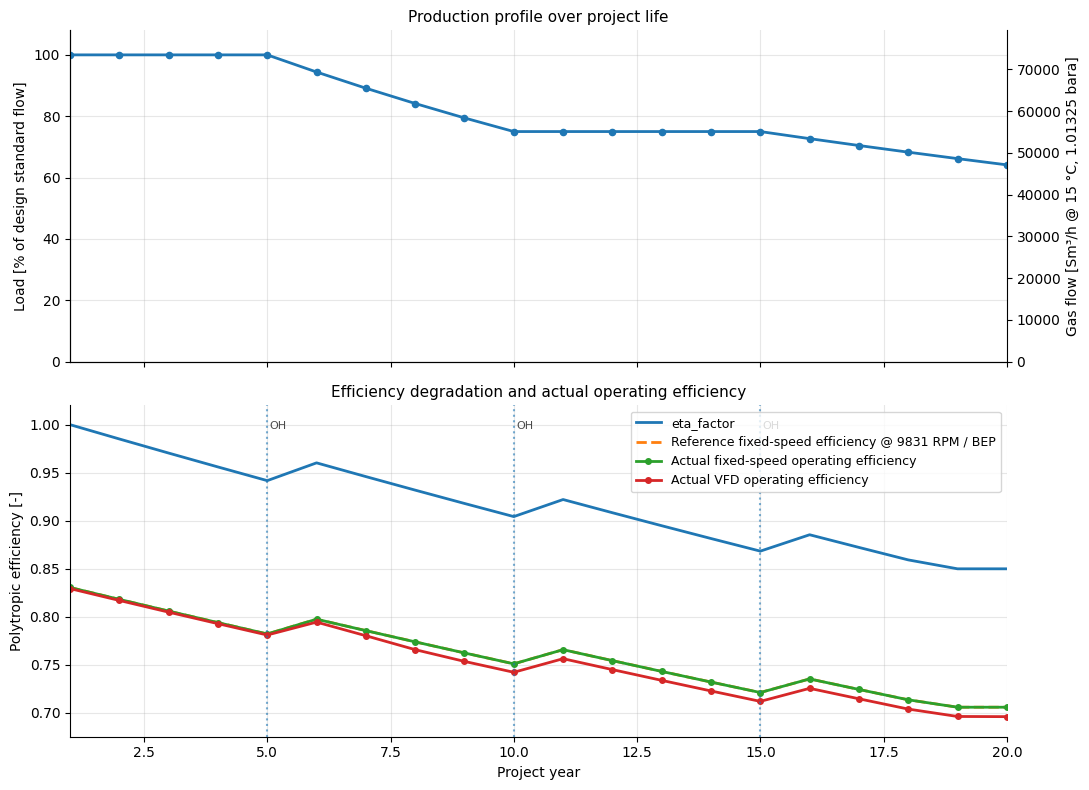

In [10]:
# ── Visual check: production profile + actual operating efficiency ─────────

op_vis = compute_annual_operating_profile(years, loads, eta_factors)
df_op  = op_vis["df"].copy()

ETA_POLY_DESIGN = float(splines[N_FIXED]['eff_bep'])
eta_poly_abs_ref = ETA_POLY_DESIGN * eta_factors   # reference-only metric at N_FIXED/BEP

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Panel 1 — Production profile
ax1.plot(years, loads * 100, linewidth=2)
ax1.scatter(years, loads * 100, s=20, zorder=3)

ax1.set_title("Production profile over project life", fontsize=11)
ax1.set_ylabel("Load [% of design standard flow]", fontsize=10)
ax1.set_xlim(1, PROJECT_LIFE)
ax1.set_ylim(0, max(loads * 100) * 1.08)
ax1.grid(True, alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# Secondary Y-axis: standard gas flow
ax1r = ax1.twinx()
ax1r.set_ylabel("Gas flow [Sm³/h @ 15 °C, 1.01325 bara]", fontsize=10)
ax1r.set_ylim(0, max(Q_std_profile) * 1.08)
ax1r.spines['top'].set_visible(False)

# Panel 2 — Health factor vs actual operating efficiencies
ax2.plot(
    years,
    eta_factors,
    linewidth=2,
    label="eta_factor"
)

ax2.plot(
    years,
    eta_poly_abs_ref,
    linewidth=2,
    linestyle="--",
    label=f"Reference fixed-speed efficiency @ {N_FIXED:.0f} RPM / BEP"
)

if not df_op.empty:
    ax2.plot(
        df_op["year"],
        df_op["eta_poly_fixed"],
        linewidth=2,
        marker="o",
        ms=4,
        label="Actual fixed-speed operating efficiency"
    )

    ax2.plot(
        df_op["year"],
        df_op["eta_poly_vfd"],
        linewidth=2,
        marker="o",
        ms=4,
        label="Actual VFD operating efficiency"
    )

# Overhaul event years at 5, 10, 15 ... (recovery appears in the following year)
overhaul_event_years = list(range(OVERHAUL_INTERVAL, PROJECT_LIFE, OVERHAUL_INTERVAL))
y_text_candidates = [np.nanmax(eta_factors), np.nanmax(eta_poly_abs_ref)]
if not df_op.empty:
    y_text_candidates.extend([
        np.nanmax(df_op["eta_poly_fixed"]),
        np.nanmax(df_op["eta_poly_vfd"]),
    ])
y_text = max(y_text_candidates) * 0.995

for y in overhaul_event_years:
    ax2.axvline(y, linestyle=":", alpha=0.6)
    ax2.text(y + 0.05, y_text, "OH", fontsize=8, alpha=0.7)

y_min_candidates = [DEGRADATION_FLOOR, np.nanmin(eta_poly_abs_ref)]
if not df_op.empty:
    y_min_candidates.extend([
        np.nanmin(df_op["eta_poly_fixed"]),
        np.nanmin(df_op["eta_poly_vfd"]),
    ])

ax2.set_title("Efficiency degradation and actual operating efficiency", fontsize=11)
ax2.set_xlabel("Project year", fontsize=10)
ax2.set_ylabel("Polytropic efficiency [-]", fontsize=10)
ax2.set_xlim(1, PROJECT_LIFE)
ax2.set_ylim(min(y_min_candidates) * 0.97, 1.02)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


Comparison Rigurous EOS vs Lapina proposed approach:

In [11]:
rows_comp = []
for year in years:
    z_yr   = annual_composition(year)
    eta_f  = annual_eta_factor(year)
    load   = annual_load(year)
    Q_std  = annual_standard_flow(year)
    Q_p    = annual_suction_flow(year, z_yr)
    MW_y   = sum(z_yr[i] * consts.MWs[i] for i in range(len(COMPONENTS)))
    price  = annual_elec_price(year)

    r_lap = compute_antisurge_fixed(Q_p, N_FIXED, eta_factor=eta_f, MW_override=MW_y)
    r_rig = compute_antisurge_rigorous(Q_p, N_FIXED, z_gas=z_yr, eta_factor=eta_f)

    if r_lap['is_valid'] and r_rig['is_valid']:
        dkW  = r_rig['power_kW'] - r_lap['power_kW']
        dpct = dkW / r_lap['power_kW'] * 100
        rows_comp.append({
            'Year':                year,
            'Load [%]':            round(load * 100, 1),
            'Q_std [Sm³/h]':       round(Q_std, 0),
            'Q_suc [m³/h]':        round(Q_p, 0),
            'MW [g/mol]':          round(MW_y, 3),
            'kW Lapina':           round(r_lap['power_kW'], 1),
            'kW Rigorous':         round(r_rig['power_kW'], 1),
            'ΔkW [%]':             round(dpct, 2),
            'Td Lapina [°C]':      round(r_lap['T_disch_C'], 1),
            'Td Rigorous [°C]':    round(r_rig['T_disch_C'], 1),
            'ΔTd [°C]':            round(r_rig['T_disch_C'] - r_lap['T_disch_C'], 2),
            'Cost delta [USD/yr]': round(abs(dkW) * HOURS_PER_YEAR * price / 1000, 0)
                if 'HOURS_PER_YEAR' in dir() else None,
        })

df_methods = pd.DataFrame(rows_comp).set_index('Year')
cross = df_methods[df_methods['ΔkW [%]'] >= 2.0]
yr_cross = cross.index[0] if len(cross) > 0 else None

print("Lapina (1982) simplified correction vs rigorous EOS")
print("Reference: Campbell TOTM Nov 2008 / Lapina (1982)\n")
display(df_methods)

print("\nKey finding:")
print(f"  ΔkW crosses 2% threshold at year {yr_cross}")
print(
    f"  Max underestimation (year 20): {df_methods['ΔkW [%]'].iloc[-1]:.2f}%  "
    f"({df_methods['kW Rigorous'].iloc[-1] - df_methods['kW Lapina'].iloc[-1]:.0f} kW)"
)
print(
    f"  Root cause: density increases +"
    f"{df_methods['MW [g/mol]'].iloc[-1] / df_methods['MW [g/mol]'].iloc[0] * 100 - 100:.1f}% "
    f"(MW drift) — Z and k vary <0.1%"
)


Lapina (1982) simplified correction vs rigorous EOS
Reference: Campbell TOTM Nov 2008 / Lapina (1982)



,Load [%],Q_std [Sm³/h],Q_suc [m³/h],MW [g/mol],kW Lapina,kW Rigorous,ΔkW [%],Td Lapina [°C],Td Rigorous [°C],ΔTd [°C],Cost delta [USD/yr]
Year,,,,,,,,,,,
1,100.0,73439.0,19250.0,27.018,5112.1,5112.1,0.00,176.7,176.7,0.00,0.0
2,100.0,73439.0,19249.0,27.116,5208.1,5227.0,0.36,179.1,179.5,0.46,13.0
3,100.0,73439.0,19249.0,27.213,5305.8,5344.4,0.73,181.5,182.4,0.94,26.0
4,100.0,73439.0,19248.0,27.310,5405.2,5464.3,1.09,183.9,185.3,1.43,41.0
5,100.0,73439.0,19248.0,27.408,5506.4,5586.7,1.46,186.3,188.3,1.94,58.0
6,94.4,69333.0,18171.0,27.499,5418.5,5516.1,1.80,184.3,186.6,2.37,72.0
7,89.1,65457.0,17155.0,27.586,5517.7,5635.1,2.13,186.7,189.5,2.83,90.0
8,84.1,61797.0,16195.0,27.668,5617.8,5754.4,2.43,189.1,192.4,3.29,108.0
9,79.4,58341.0,15289.0,27.745,5718.6,5874.3,2.72,191.5,195.3,3.73,126.0



Key finding:
  ΔkW crosses 2% threshold at year 7
  Max underestimation (year 20): 5.61%  (356 kW)
  Root cause: density increases +5.5% (MW drift) — Z and k vary <0.1%


---
## 6. DWSIM validation — Approach A vs Approach B

### Why validate against DWSIM?

`thermo` and DWSIM both implement Peng-Robinson, but via independent numerical paths
with different Cp correlations for enthalpy departure. Validating at the same operating
points quantifies whether Approach A is reliable for this gas — and reveals exactly
where and why the two implementations diverge.

Validation runs **before** the economic model in this notebook: results here justify
using Approach A for the 20-year sweep in Sections 7 and 8.

### Flowsheet structure

```
[FEED] ──► [Compressor C-1] ──► [DISCHARGE]
```

- Property package: **Peng-Robinson**
- Compressor mode: **Outlet Pressure** (polytropic)
- Feed: design composition (year 1), P = 4.08 bar, T = 33.6 °C
- Outlet pressure: set from Python model for each BEP point

Save the flowsheet at:
`C:\Users\<your_user>\Desktop\compressor_data\Compressor_Validation.dwxmz`

### Key pythonnet lessons learned

Three non-obvious requirements for DWSIM automation with pythonnet 3.x:

1. **Use `__implementation__`** — objects from `fs.SimulationObjects.Values` are
   `ISimulationObject` interface. Direct property access requires the concrete type:
   ```python
   obj.__implementation__  # → DWSIM.UnitOperations.UnitOperations.Compressor
   ```

2. **`SetPropertyValue` is silently ignored** for compressor inputs. Use direct
   .NET property assignment instead:
   ```python
   comp.POut                 = P_Pa    # works
   comp.PolytropicEfficiency = pct     # works
   comp.SetPropertyValue("PROP_CO_4", P_Pa)  # silently ignored
   ```

3. **Enums require explicit casting** in pythonnet 3.x:
   ```python
   comp.CalcMode = CalcModeEnum(0)   # OutletPressure — correct
   comp.CalcMode = 0                  # TypeError — incorrect
   ```

### Why Outlet Pressure mode (not Known Head)?

Known Head mode introduces a unit conversion ambiguity: DWSIM converts metres to
kJ/kg using its own internal density, not ours. This creates a 1% head discrepancy
that propagates into pressure and temperature. Outlet Pressure mode takes P_disch
directly — eliminating this artefact and isolating the true thermodynamic difference.

### Root cause of residual differences

Diagnostics at the design BEP (9831 RPM):

| Property | thermo | DWSIM | Difference |
|---|---|---|---|
| Density ρ [kg/m³] | 4.3755 | 4.3738 | −0.037% |
| Suction enthalpy h₁ [J/mol] | 219.88 | 219.21 | −0.306% |

Density agrees to 0.04% — the EOS parameters (kijs, Tc, Pc, ω) are effectively
identical. The 0.3% enthalpy difference originates from **independent Cp correlations**:
`thermo` uses DIPPR/Yaws polynomials; DWSIM uses its own internal database.
This h₁ difference propagates to ~2% power deviation and ~3°C temperature deviation
at high speeds — both within the uncertainty of any real plant measurement.


In [12]:
# DWSIM_PATH and SIM_FILE defined in Section 0

DWSIM_AVAILABLE = False
auto = None
fs   = None

try:
    import clr
    if DWSIM_PATH not in sys.path:
        sys.path.append(DWSIM_PATH)
    clr.AddReference("DWSIM.Automation")
    clr.AddReference("DWSIM.Interfaces")
    clr.AddReference("DWSIM.UnitOperations")
    from DWSIM.Automation import Automation3
    from DWSIM.UnitOperations.UnitOperations import Compressor as DWSIMCompressor

    CalcModeEnum    = DWSIMCompressor.CalculationMode
    ProcessPathEnum = DWSIMCompressor.ProcessPathType

    auto = Automation3()
    fs   = auto.LoadFlowsheet(SIM_FILE)
    DWSIM_AVAILABLE = True
    print(f"DWSIM loaded: {SIM_FILE.split(chr(92))[-1]}")
    print(f"CalcMode enum  — OutletPressure={int(CalcModeEnum(0))}  Head={int(CalcModeEnum(4))}")
    print(f"ProcessPath    — Polytropic={int(ProcessPathEnum(1))}")

except Exception as e:
    print(f"DWSIM not available: {e}")
    print("Build the flowsheet and re-run to populate the validation table.")


def discover_objects(fs):
    """
    Auto-discover FEED, Compressor, and DISCHARGE from the flowsheet.

    The compressor is selected by concrete .NET type.
    Material streams are ranked by pressure so the lowest-pressure stream is
    interpreted as suction and the highest-pressure stream as discharge.
    This is more robust than relying on collection ordering.
    """
    material_streams, compressors = [], []
    for obj in fs.SimulationObjects.Values:
        impl = obj.__implementation__
        name = type(impl).__name__
        if name == "MaterialStream":
            material_streams.append(impl)
        elif name == "Compressor":
            compressors.append(impl)

    if not material_streams or not compressors:
        raise RuntimeError("Could not auto-discover MaterialStream / Compressor objects.")

    def _safe_pressure_bar(stream):
        try:
            return float(stream.GetPropertyValue("PROP_MS_1")) / 1e5
        except Exception:
            return float("nan")

    ranked_streams = sorted(material_streams, key=lambda s: (_safe_pressure_bar(s), str(getattr(s, "Tag", ""))))
    feed      = ranked_streams[0]
    discharge = ranked_streams[-1]
    comp      = compressors[0]
    return feed, comp, discharge


def dwsim_compute(Q_m3h: float, N_rpm: float,
                   eta_factor: float = 1.0,
                   z_gas: list = None) -> dict:
    """
    Run DWSIM compressor at (Q, N) and return power, P_disch, T_disch.

    Strategy: Outlet Pressure mode — Python provides P_disch and eta_poly,
    DWSIM computes T_disch and power via its own PR implementation.
    This isolates the pure thermodynamic difference between thermo and DWSIM.

    Current scope in v15:
      - validated for the Section 0 design composition only
      - feed composition updates are intentionally blocked until a robust
        composition write-back path is implemented
    """
    if not DWSIM_AVAILABLE:
        return {"is_valid": False, "reason": "DWSIM not available"}

    if z_gas is not None:
        return {
            "is_valid": False,
            "reason": "dwsim_compute currently validates design composition only; feed composition update is not implemented in v15."
        }

    feed, comp, disch = discover_objects(fs)

    # ── Set feed mass flow ────────────────────────────────────────────────
    m_dot = (Q_m3h / 3600.0) * RHO_DESIGN
    feed.SetPropertyValue("PROP_MS_0", T_SUC_K)    # Temperature [K]
    feed.SetPropertyValue("PROP_MS_1", P_SUC_PA)   # Pressure [Pa]
    feed.SetPropertyValue("PROP_MS_2", m_dot)      # Mass flow [kg/s]

    # ── Get Python reference point ────────────────────────────────────────
    r_py = compute_operating_point(Q_m3h, N_rpm, eta_factor=eta_factor)
    if not r_py['is_valid']:
        return {"is_valid": False, "reason": "Python compute failed"}

    # ── Set compressor via direct .NET properties ─────────────────────────
    # SetPropertyValue() is silently ignored for compressor inputs.
    # Must use direct property assignment on __implementation__ object.
    comp.CalcMode             = CalcModeEnum(0)            # OutletPressure
    comp.ProcessPath          = ProcessPathEnum(1)         # Polytropic
    comp.PolytropicEfficiency = r_py['eta_poly'] * 100.0   # [%]
    comp.POut                 = r_py['P_disch_bar'] * 1e5  # [Pa]

    # ── Recalculate flowsheet ─────────────────────────────────────────────
    auto.CalculateFlowsheet2(fs)

    # ── Re-fetch objects after recalc ─────────────────────────────────────
    _, comp, disch = discover_objects(fs)

    power_kW    = float(comp.DeltaQ)                                     # kW
    P_disch_bar = float(comp.POut) / 1e5                                 # bar
    T_disch_C   = float(disch.GetPropertyValue("PROP_MS_0")) - 273.15    # °C

    return {
        "is_valid":    True,
        "Q_m3h":       Q_m3h,
        "N_rpm":       N_rpm,
        "power_kW":    power_kW,
        "P_disch_bar": P_disch_bar,
        "T_disch_C":   T_disch_C,
    }


DWSIM loaded: Compressor_Validation.dwxmz
CalcMode enum  — OutletPressure=0  Head=4
ProcessPath    — Polytropic=1


In [13]:
# ── Validation: thermo (PR EOS) vs DWSIM (PR EOS) — design composition, BEP points ──
print("=== thermo (PR EOS) vs DWSIM (PR EOS) ===")
print("Design composition (year 1) \u2014 BEP operating point at each speed\n")

val_rows = []
for N in SPEEDS:
    Q_bep = splines[N]['Q_bep']
    r_py  = compute_operating_point(Q_bep, N)
    if DWSIM_AVAILABLE:
        try:
            r_dw = dwsim_compute(Q_bep, N)
            val_rows.append({
                "N [RPM]":          int(N),
                "Q_bep [m\u00b3/h]":   int(Q_bep),
                "kW thermo":        round(r_py['power_kW'], 1),
                "kW DWSIM":         round(r_dw['power_kW'], 1),
                "\u0394kW%":            round((r_dw['power_kW']-r_py['power_kW'])/r_py['power_kW']*100, 2),
                "Pd thermo [bar]":  round(r_py['P_disch_bar'], 3),
                "Pd DWSIM [bar]":   round(r_dw['P_disch_bar'], 3),
                "\u0394Pd%":            round((r_dw['P_disch_bar']-r_py['P_disch_bar'])/r_py['P_disch_bar']*100, 2),
                "Td thermo [\u00b0C]":  round(r_py['T_disch_C'], 1),
                "Td DWSIM [\u00b0C]":   round(r_dw['T_disch_C'], 1),
                "\u0394Td [\u00b0C]":       round(r_dw['T_disch_C']-r_py['T_disch_C'], 2),
            })
        except Exception as e:
            print(f"N={N} RPM: {e}")
    else:
        val_rows.append({
            "N [RPM]": int(N), "Q_bep [m\u00b3/h]": int(Q_bep),
            "kW thermo": round(r_py['power_kW'], 1),
            "kW DWSIM": "\u2014", "\u0394kW%": "\u2014",
            "Pd thermo [bar]": round(r_py['P_disch_bar'], 3),
            "Pd DWSIM [bar]": "\u2014", "\u0394Pd%": "\u2014",
            "Td thermo [\u00b0C]": round(r_py['T_disch_C'], 1),
            "Td DWSIM [\u00b0C]": "\u2014", "\u0394Td [\u00b0C]": "\u2014",
        })

df_val = pd.DataFrame(val_rows).set_index("N [RPM]")
display(df_val)

if DWSIM_AVAILABLE:
    print("\nRoot cause diagnostic:")
    suc        = flasher.flash(T=T_SUC_K, P=P_SUC_PA, zs=Z_GAS_DESIGN)
    feed, _, _ = discover_objects(fs)
    h1_thermo  = suc.gas.H()
    h1_dw_Jmol = float(feed.GetPropertyValue("PROP_MS_7")) * 1000.0 * (MW_DESIGN/1000.0)
    rho_thermo = suc.gas.rho_mass()
    rho_dw     = float(feed.GetPropertyValue("PROP_MS_5"))
    print(f"  h\u2081 thermo = {h1_thermo:.2f} J/mol")
    print(f"  h\u2081 DWSIM  = {h1_dw_Jmol:.2f} J/mol  "
          f"(\u0394 = {(h1_dw_Jmol-h1_thermo)/abs(h1_thermo)*100:.3f}%)")
    print(f"  \u03c1 thermo  = {rho_thermo:.4f} kg/m\u00b3")
    print(f"  \u03c1 DWSIM   = {rho_dw:.4f} kg/m\u00b3  "
          f"(\u0394 = {(rho_dw-rho_thermo)/rho_thermo*100:.3f}%)")
    print("\nConclusion:")
    print("  \u03c1 agrees to 0.04% \u2014 EOS parameters effectively identical")
    print("  h\u2081 differs by 0.3% \u2014 independent Cp correlations (DIPPR/Yaws vs DWSIM)")
    print("  Power agreement: within 2.4% across all speeds \u2014 Approach A validated")
else:
    print("\nExpected: power within 2.4%, T_disch within 3\u00b0C across all speeds.")


=== thermo (PR EOS) vs DWSIM (PR EOS) ===
Design composition (year 1) — BEP operating point at each speed



,Q_bep [m³/h],kW thermo,kW DWSIM,ΔkW%,Pd thermo [bar],Pd DWSIM [bar],ΔPd%,Td thermo [°C],Td DWSIM [°C],ΔTd [°C]
N [RPM],,,,,,,,,,
6882,11250,1433.9,1421.8,-0.84,8.982,8.982,0.0,107.3,106.8,-0.51
7865,13708,2263.6,2237.0,-1.17,11.308,11.308,0.0,127.9,127.1,-0.90
8848,16375,3433.4,3377.4,-1.63,14.505,14.505,0.0,151.7,150.2,-1.55
9831,19250,5020.5,4913.2,-2.14,18.892,18.892,0.0,178.3,175.8,-2.46
10322,21500,6113.1,5966.8,-2.39,21.204,21.204,0.0,190.2,187.2,-2.97



Root cause diagnostic:
  h₁ thermo = 219.88 J/mol
  h₁ DWSIM  = 219.21 J/mol  (Δ = -0.306%)
  ρ thermo  = 4.3755 kg/m³
  ρ DWSIM   = 4.3738 kg/m³  (Δ = -0.037%)

Conclusion:
  ρ agrees to 0.04% — EOS parameters effectively identical
  h₁ differs by 0.3% — independent Cp correlations (DIPPR/Yaws vs DWSIM)
  Power agreement: within 2.4% across all speeds — Approach A validated


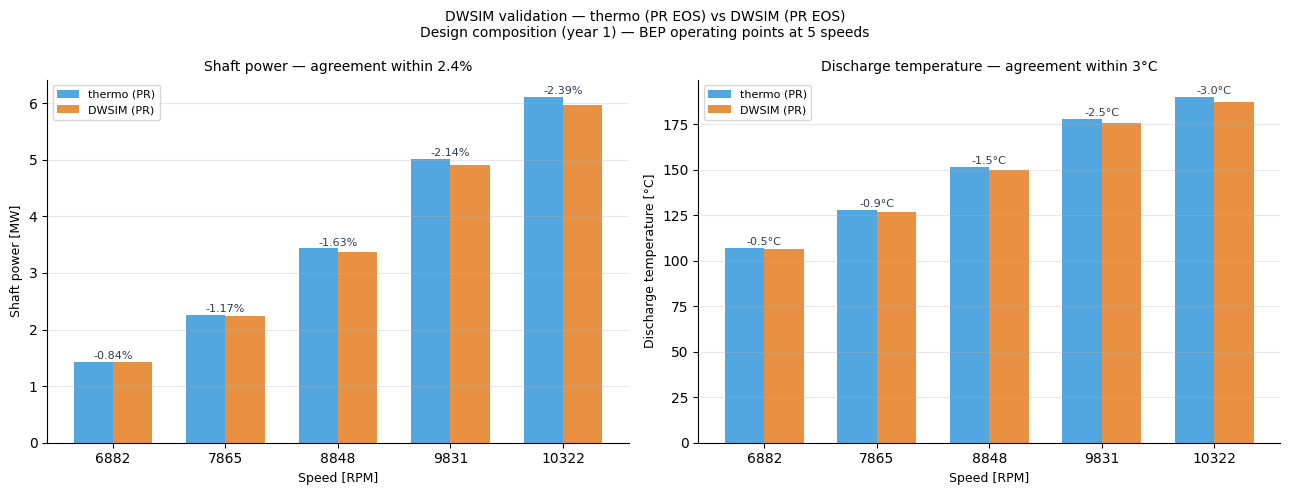

In [14]:
# ── Validation plot: thermo (PR) vs DWSIM (PR) ───────────────────────────
if DWSIM_AVAILABLE:
    val_data = []
    for N in SPEEDS:
        Q_bep = splines[N]['Q_bep']
        r_py  = compute_operating_point(Q_bep, N)
        try:
            r_dw = dwsim_compute(Q_bep, N)
            val_data.append({
                'N': N,
                'kW_py': r_py['power_kW'],
                'kW_dw': r_dw['power_kW'],
                'dkW_pct': (r_dw['power_kW'] - r_py['power_kW']) / r_py['power_kW'] * 100,
                'Td_py': r_py['T_disch_C'],
                'Td_dw': r_dw['T_disch_C'],
                'dTd': r_dw['T_disch_C'] - r_py['T_disch_C'],
            })
        except Exception:
            pass

    if val_data:
        df_val = pd.DataFrame(val_data)
        speeds_str = [f"{int(n)}" for n in df_val['N']]
        x = np.arange(len(speeds_str))
        w = 0.35

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(
            'DWSIM validation \u2014 thermo (PR EOS) vs DWSIM (PR EOS)\n'
            'Design composition (year 1) \u2014 BEP operating points at 5 speeds',
            fontsize=10, fontweight='normal'
        )

        ax1.bar(x - w/2, df_val['kW_py']/1000, w, label='thermo (PR)',
                color='#3498db', alpha=0.85)
        ax1.bar(x + w/2, df_val['kW_dw']/1000, w, label='DWSIM (PR)',
                color='#e67e22', alpha=0.85)
        for i, (v_py, v_dw, dpct) in enumerate(zip(df_val['kW_py'],
                                                     df_val['kW_dw'],
                                                     df_val['dkW_pct'])):
            ax1.annotate(f'{dpct:+.2f}%',
                         xy=(x[i], max(v_py, v_dw)/1000 + 0.05),
                         ha='center', fontsize=8, color='#2c3e50')
        ax1.set_xticks(x); ax1.set_xticklabels(speeds_str)
        ax1.set_xlabel('Speed [RPM]', fontsize=9)
        ax1.set_ylabel('Shaft power [MW]', fontsize=9)
        ax1.set_title('Shaft power — agreement within 2.4%', fontsize=10)
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.spines[['top', 'right']].set_visible(False)

        ax2.bar(x - w/2, df_val['Td_py'], w, label='thermo (PR)',
                color='#3498db', alpha=0.85)
        ax2.bar(x + w/2, df_val['Td_dw'], w, label='DWSIM (PR)',
                color='#e67e22', alpha=0.85)
        for i, (v_py, v_dw, dTd) in enumerate(zip(df_val['Td_py'],
                                                    df_val['Td_dw'],
                                                    df_val['dTd'])):
            ax2.annotate(f'{dTd:+.1f}\u00b0C',
                         xy=(x[i], max(v_py, v_dw) + 1.5),
                         ha='center', fontsize=8, color='#2c3e50')
        ax2.set_xticks(x); ax2.set_xticklabels(speeds_str)
        ax2.set_xlabel('Speed [RPM]', fontsize=9)
        ax2.set_ylabel('Discharge temperature [\u00b0C]', fontsize=9)
        ax2.set_title('Discharge temperature — agreement within 3\u00b0C', fontsize=10)
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.spines[['top', 'right']].set_visible(False)

        plt.tight_layout()
        plt.show()
else:
    print("DWSIM not available \u2014 validation plot requires a DWSIM connection.")
    print("Expected results: power within 2.4%, discharge temperature within 3\u00b0C.")
    print("Root cause of residual difference: \u0394h\u2081 = 0.3% from Cp correlations (DIPPR vs DWSIM).")


---
## 7. 20-year economic analysis — CAPEX / OPEX / NPV

### Economic parameters

| Parameter | Value | Description |
|---|---|---|
| `HOURS_PER_YEAR` | 8,000 h | Annual operating hours |
| `ELEC_PRICE_BASE` | 0.08 USD/kWh | Base electricity price |
| `ELEC_ESCALATION` | 3% | Annual electricity price escalation |
| `DISCOUNT_RATE` | 8% | Cost of capital / minimum acceptable return |
| `VFD_USD_KW` | 250 USD/kW | MV drive installed CAPEX (150–350 USD/kW range) |
| `VFD_INSTALL_F` | 1.30 | Installation factor (cabling, engineering, commissioning) |

### Key financial concepts

**NPV (Net Present Value)**: sum of discounted future savings minus CAPEX.
`NPV = Σ [Saving_t / (1 + r)^t] − CAPEX`. Positive NPV means the investment
creates value above the cost of capital.

**IRR (Internal Rate of Return)**: discount rate at which NPV = 0. If IRR exceeds
the cost of capital (8%), the investment is attractive.

**Simple payback**: years until cumulative undiscounted savings recover CAPEX.
**Discounted payback**: years until cumulative NPV turns positive.

### R_P_REQUIRED sensitivity

The discharge pressure constraint (`R_P_REQUIRED`) directly affects VFD economics.
With `R_P_REQUIRED = None` (pure antisurge model), the VFD achieves maximum saving.
Setting a finite value forces the VFD to operate faster during decline phases,
reducing saving. The sensitivity table below quantifies this effect.

### Model — all effects combined

Each annual cash flow uses the **rigorous EOS method**, incorporating:
- Actual gas composition (full flash per year, coupled to cumulative production)
- Exponential efficiency degradation + partial overhaul recovery
- Production load profile (plateau → decline → plateau → decline)
- Electricity price escalation at 3% per year
- VFD constraint model (pure antisurge or dual constraint per R_P_REQUIRED)


In [15]:
_SECTION7_CASHFLOW_CACHE = {}


def _copy_cashflow_result(result: dict) -> dict:
    """Return a safe copy of the cached cashflow result."""
    copied = {}
    for key, value in result.items():
        copied[key] = value.copy(deep=True) if isinstance(value, pd.DataFrame) else value
    return copied


def clear_section7_caches():
    """Clear reusable caches for Section 4 / Section 5 / Section 7 comparisons."""
    _ANTISURGE_EVAL_CACHE.clear()
    _SECTION5_OPERATING_CACHE.clear()
    _SECTION7_CASHFLOW_CACHE.clear()


def _interpolated_crossing_time(x, y, target, y0_at_t0, cross_tol=CROSS_TOL):
    """
    Return interpolated time when cumulative series y crosses a target value.
    """
    x_vals = np.asarray(x, dtype=float)
    y_vals = np.asarray(y, dtype=float)

    idx = np.where(y_vals >= target)[0]
    if len(idx) == 0:
        return float("inf")

    i = idx[0]
    if i == 0:
        x0, yy0 = 0.0, y0_at_t0
        x1, yy1 = x_vals[0], y_vals[0]
    else:
        x0, yy0 = x_vals[i - 1], y_vals[i - 1]
        x1, yy1 = x_vals[i], y_vals[i]

    if not np.isfinite(yy1 - yy0) or abs(yy1 - yy0) < cross_tol:
        return float(x1)

    frac = (target - yy0) / (yy1 - yy0)
    frac = min(max(frac, 0.0), 1.0)
    return float(x0 + frac * (x1 - x0))


def compute_annual_cashflows(years, loads, etas, prices,
                             N_fixed=N_FIXED,
                             vfd_USD_kW=VFD_USD_KW,
                             vfd_install=VFD_INSTALL_F,
                             discount_rate=DISCOUNT_RATE,
                             hours_per_year=HOURS_PER_YEAR,
                             r_p_req=_RP_USE_GLOBAL,
                             overhaul_interval=OVERHAUL_INTERVAL,
                             irr_lower=IRR_LOWER_BOUND,
                             irr_upper=IRR_UPPER_BOUND,
                             irr_xtol=IRR_XTOL,
                             cross_tol=CROSS_TOL) -> dict:
    """
    Compute annual cash flows for both strategies from the precomputed annual
    operating profile.

    Production inputs (`loads`) are interpreted as fractions of design standard
    flow [Sm³/h]. The annual technical profile is built first; the economic
    layer is applied afterwards.
    """
    year_arr  = np.asarray(years, dtype=int)
    load_arr  = np.asarray(loads, dtype=float)
    eta_arr   = np.asarray(etas, dtype=float)
    price_arr = np.asarray(prices, dtype=float)
    r_p_eff   = _resolve_r_p_req(r_p_req)

    scenario_key = (
        tuple(int(y) for y in year_arr),
        tuple(round(float(v), 8) for v in load_arr),
        tuple(round(float(v), 8) for v in eta_arr),
        tuple(round(float(v), 8) for v in price_arr),
        round(float(N_fixed), 6),
        round(float(vfd_USD_kW), 6),
        round(float(vfd_install), 6),
        round(float(discount_rate), 8),
        round(float(hours_per_year), 6),
        None if r_p_eff is None else round(float(r_p_eff), 6),
        int(overhaul_interval),
        round(float(irr_lower), 8),
        round(float(irr_upper), 8),
        round(float(irr_xtol), 12),
        round(float(cross_tol), 16),
    )

    if scenario_key in _SECTION7_CASHFLOW_CACHE:
        return _copy_cashflow_result(_SECTION7_CASHFLOW_CACHE[scenario_key])

    op = compute_annual_operating_profile(
        years, loads, etas,
        N_fixed=N_fixed,
        r_p_req=r_p_eff,
    )
    df = op["df"].copy(deep=True)

    if df.empty:
        result = {
            "df": df,
            "capex_vfd": float("nan"),
            "kW_peak": float("nan"),
            "npv_total": float("nan"),
            "saving_total": 0.0,
            "payback": float("inf"),
            "payback_disc": float("inf"),
            "irr": float("nan"),
            "discount_rate": discount_rate,
            "n_pressure": 0,
            "n_nmax_recycle": 0,
        }
        _SECTION7_CASHFLOW_CACHE[scenario_key] = _copy_cashflow_result(result)
        return _copy_cashflow_result(result)

    price_map = {int(y): float(p) for y, p in zip(year_arr, price_arr)}
    df["elec_price"] = df["year"].map(price_map)

    E_fixed_kWh = df["kW_fixed"] * hours_per_year
    E_vfd_kWh   = df["kW_vfd"]   * hours_per_year

    df["E_fixed_MWh"] = E_fixed_kWh / 1000.0
    df["E_vfd_MWh"]   = E_vfd_kWh / 1000.0
    df["cost_fixed"]  = E_fixed_kWh * df["elec_price"]
    df["cost_vfd"]    = E_vfd_kWh   * df["elec_price"]
    df["saving_USD"]  = df["cost_fixed"] - df["cost_vfd"]

    df["disc_factor"] = 1 / (1 + discount_rate) ** df["year"]
    df["saving_pv"]   = df["saving_USD"] * df["disc_factor"]
    df["saving_cum"]  = df["saving_USD"].cumsum()

    kW_peak   = float(df["kW_fixed"].max())
    capex_vfd = float(kW_peak * vfd_USD_kW * vfd_install)

    df["npv_cum"] = df["saving_pv"].cumsum() - capex_vfd

    payback = _interpolated_crossing_time(
        df["year"].values,
        df["saving_cum"].values,
        target=capex_vfd,
        y0_at_t0=0.0,
        cross_tol=cross_tol,
    )

    payback_disc = _interpolated_crossing_time(
        df["year"].values,
        df["npv_cum"].values,
        target=0.0,
        y0_at_t0=-capex_vfd,
        cross_tol=cross_tol,
    )

    cashflows = [-capex_vfd] + list(df["saving_USD"])
    try:
        irr = brentq(
            lambda r: sum(f / (1 + r) ** t for t, f in enumerate(cashflows)),
            irr_lower,
            irr_upper,
            xtol=irr_xtol
        )
    except Exception:
        irr = float("nan")

    result = {
        "df": df,
        "capex_vfd": capex_vfd,
        "kW_peak": kW_peak,
        "npv_total": float(df["npv_cum"].iloc[-1]),
        "saving_total": float(df["saving_USD"].sum()),
        "payback": payback,
        "payback_disc": payback_disc,
        "irr": irr,
        "discount_rate": discount_rate,
        "n_pressure": int((df["constraint"] == "pressure").sum()),
        "n_nmax_recycle": int((df["constraint"] == "N_max+recycle").sum()),
    }

    _SECTION7_CASHFLOW_CACHE[scenario_key] = _copy_cashflow_result(result)
    return _copy_cashflow_result(result)


In [16]:
clear_section7_caches()

In [17]:
op    = compute_annual_operating_profile(years, loads, eta_factors)
df_op = op["df"]

fc    = compute_annual_cashflows(years, loads, eta_factors, elec_prices)
df_fc = fc["df"]


In [18]:
display(df_fc)
display(pd.DataFrame([fc]).T)

,year,load_pct,Q_std_Sm3h,Q_process,eta_factor,MW,overhaul,kW_fixed,kW_vfd,saving_kW,...,elec_price,E_fixed_MWh,E_vfd_MWh,cost_fixed,cost_vfd,saving_USD,disc_factor,saving_pv,saving_cum,npv_cum
0,1,100.000000,73439.303104,19250.000000,1.000000,27.018170,False,5112.107755,4836.453508,275.654247,...,0.080000,40896.862038,38691.628061,3.271749e+06,3.095330e+06,1.764187e+05,0.925926,163350.664990,1.764187e+05,-2.015383e+06
1,2,100.000000,73439.303104,19249.457069,0.985112,27.115507,False,5227.033591,4944.920798,282.112793,...,0.082400,41816.268727,39559.366385,3.445661e+06,3.259692e+06,1.859688e+05,0.857339,159438.231330,3.623875e+05,-1.855945e+06
2,3,100.000000,73439.303104,19248.912193,0.970446,27.212844,False,5344.406116,5055.690143,288.715973,...,0.084872,42755.248926,40445.521145,3.628723e+06,3.432692e+06,1.960312e+05,0.793832,155615.899734,5.584187e+05,-1.700329e+06
3,4,100.000000,73439.303104,19248.365407,0.955997,27.310178,False,5464.274351,5168.807500,295.466851,...,0.087418,43714.194808,41350.459998,3.821414e+06,3.614781e+06,2.066333e+05,0.735030,151881.679209,7.650520e+05,-1.548447e+06
4,5,100.000000,73439.303104,19247.816637,0.941765,27.407515,False,5586.690905,5284.322150,302.368755,...,0.090041,44693.527237,42274.577197,4.024237e+06,3.806433e+06,2.178040e+05,0.680583,148233.719825,9.828560e+05,-1.400213e+06
5,6,94.408751,69333.128899,18171.132492,0.960259,27.499411,True,5516.106157,4660.894611,855.211547,...,0.092742,44128.849259,37287.156885,4.092594e+06,3.458083e+06,6.345117e+05,0.630170,399850.018574,1.617368e+06,-1.000363e+06
6,7,89.130123,65456.541113,17154.700392,0.945963,27.586166,False,5635.061093,4191.879539,1443.181553,...,0.095524,45080.488740,33535.036314,4.306277e+06,3.203407e+06,1.102870e+06,0.583490,643514.004831,2.720238e+06,-3.568494e+05
7,8,84.146636,61796.702997,16195.146035,0.931879,27.668072,False,5754.439026,3712.211993,2042.227032,...,0.098390,46035.512206,29697.695947,4.529430e+06,2.921954e+06,1.607476e+06,0.540269,868469.405171,4.327714e+06,5.116201e+05
8,9,79.441788,58341.495539,15289.284408,0.918005,27.745397,False,5874.292407,3696.492874,2177.799532,...,0.101342,46994.339253,29571.942993,4.762482e+06,2.996868e+06,1.765614e+06,0.500249,883246.392856,6.093328e+06,1.394866e+06
9,10,75.000000,55079.477328,14434.109033,0.904338,27.818399,False,5994.675153,3759.978126,2234.697028,...,0.104382,47957.401227,30079.825005,5.005882e+06,3.139788e+06,1.866095e+06,0.463193,864362.850053,7.959422e+06,2.259229e+06


,0
df,year load_pct Q_std_Sm3h Q_proce...
capex_vfd,2178733.571653
kW_peak,6703.795605
npv_total,9700549.401597
saving_total,32671918.636682
payback,6.509005
payback_disc,7.410895
irr,0.268838
discount_rate,0.08
n_pressure,12


## 7b — Sensitivity: NPV / IRR vs R_P_REQUIRED

The dual-constraint VFD model allows the downstream pressure requirement (R_P_REQUIRED) to be varied independently. This table sweeps candidate values and reports the key financial metrics alongside the constraint breakdown.

All calls reuse the Section 7 cashflow cache — no recomputation.

In [19]:
_RP_SWEEP = [None, 2.5, 3.0, 3.5, 4.0, 4.56]   # None = pure antisurge

def _safe(val, scale=1.0):
    """Return scaled value or NaN if not finite."""
    return float(val) * scale if np.isfinite(float(val)) else np.nan

sensitivity_rows = []
for r_p_s in _RP_SWEEP:
    fc_s = compute_annual_cashflows(
        years, loads, eta_factors, elec_prices,
        r_p_req=r_p_s,
    )
    df_s  = fc_s["df"]
    empty = df_s.empty
    sensitivity_rows.append({
        "COMP_RATIO":        "None (antisurge)" if r_p_s is None else r_p_s,
        "P_disch_bar":    np.nan if r_p_s is None else round(r_p_s * P_SUC_BAR, 2),
        "NPV_MMUSD":      _safe(fc_s["npv_total"], 1e-6),
        "IRR_pct":        _safe(fc_s["irr"], 100.0),
        "Payback_y":      _safe(fc_s["payback"]),
        "Payback_disc_y": _safe(fc_s["payback_disc"]),
        "Yrs_antisurge":  0 if empty else int((df_s["constraint"] == "antisurge").sum()),
        "Yrs_pressure":   0 if empty else int((df_s["constraint"] == "pressure").sum()),
    })

df_sensitivity = pd.DataFrame(sensitivity_rows)

print("Sensitivity: NPV / IRR vs COMP_RATIO (R_P_REQUIRED)\n")
display(
    df_sensitivity.round({
        "NPV_MMUSD":      2,
        "IRR_pct":        1,
        "Payback_y":      1,
        "Payback_disc_y": 1,
    })
)

Sensitivity: NPV / IRR vs COMP_RATIO (R_P_REQUIRED)



,COMP_RATIO,P_disch_bar,NPV_MMUSD,IRR_pct,Payback_y,Payback_disc_y,Yrs_antisurge,Yrs_pressure
0,None (antisurge),NaN,13.89,29.4,6.5,7.4,20,0
1,2.5,10.20,13.74,29.3,6.5,7.4,17,3
2,3.0,12.24,12.54,28.9,6.5,7.4,9,11
3,3.5,14.28,9.70,26.9,6.5,7.4,8,12
4,4.0,16.32,6.08,22.9,6.6,7.8,6,14
5,4.56,18.60,0.40,9.4,11.8,17.8,0,20


---
## 8. Financial dashboard


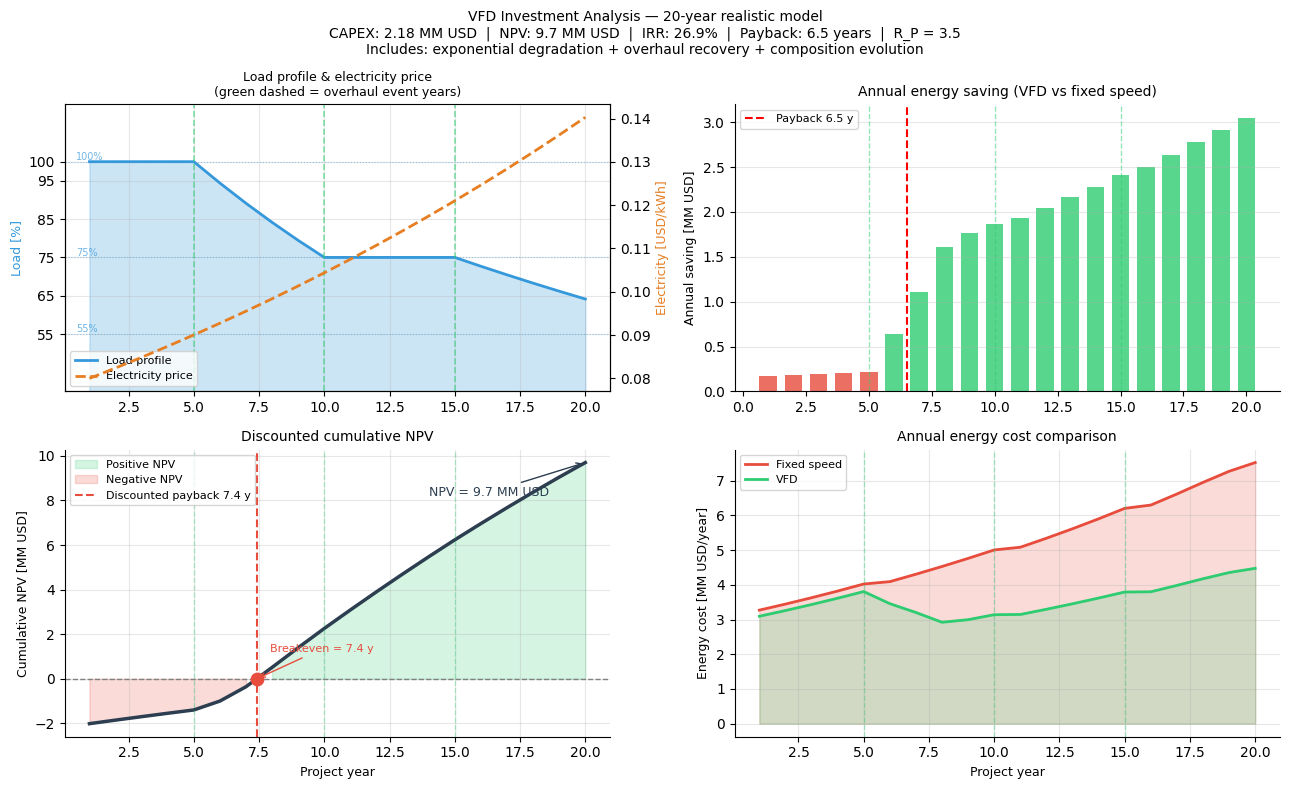

In [20]:
# ── Financial dashboard ───────────────────────────────────────────────────

# Ensure annual operating / financial results exist
op    = compute_annual_operating_profile(years, loads, eta_factors)
df_op = op["df"]

fc    = compute_annual_cashflows(years, loads, eta_factors, elec_prices)
df_fc = fc["df"]

if df_fc.empty:
    raise ValueError("df_fc is empty. Check Section 5/7 calculations before plotting the dashboard.")

rp_label = f"R_P = {R_P_REQUIRED}" if R_P_REQUIRED is not None else "R_P = None (antisurge only)"
overhaul_event_years = list(range(OVERHAUL_INTERVAL, PROJECT_LIFE, OVERHAUL_INTERVAL))   # 5, 10, 15

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(
    'VFD Investment Analysis — 20-year realistic model\n'
    f'CAPEX: {fc["capex_vfd"]/1e6:.2f} MM USD  |  '
    f'NPV: {fc["npv_total"]/1e6:.1f} MM USD  |  '
    f'IRR: {fc["irr"]*100:.1f}%  |  '
    f'Payback: {fc["payback"]:.1f} years  |  '
    f'{rp_label}\n'
    'Includes: exponential degradation + overhaul recovery + composition evolution',
    fontsize=10, fontweight='normal'
)

ap = df_fc['year']

# Panel 1 ─ Load profile & electricity price
ax = axes[0, 0]
ax2 = ax.twinx()

ax.fill_between(ap, df_fc['load_pct'], alpha=0.25, color='#3498db')
ax.plot(ap, df_fc['load_pct'], color='#3498db', linewidth=2, label='Load profile')

ax2.plot(
    ap, df_fc['elec_price'],
    color='#e67e22', linewidth=2, linestyle='--',
    label='Electricity price'
)

ax.set_ylim(40, 115)
ax.set_yticks([55, 65, 75, 85, 95, 100])

for nivel in [100, 75, 55]:
    ax.axhline(nivel, color='#3498db', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.text(0.5, nivel + 0.5, f'{nivel}%', fontsize=7, color='#3498db', alpha=0.7)

for oh_yr in overhaul_event_years:
    ax.axvline(oh_yr, color='#2ecc71', linewidth=1.2, linestyle='--', alpha=0.6)

ax.set_ylabel('Load [%]', color='#3498db', fontsize=9)
ax2.set_ylabel('Electricity [USD/kWh]', color='#e67e22', fontsize=9)
ax.set_title('Load profile & electricity price\n(green dashed = overhaul event years)', fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines[['top']].set_visible(False)

l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lb1 + lb2, fontsize=8, loc='lower left')

# Panel 2 ─ Annual saving
ax = axes[0, 1]
ax.bar(
    ap,
    df_fc['saving_USD'] / 1e6,
    color=['#e74c3c' if v < 0.5e6 else '#2ecc71' for v in df_fc['saving_USD']],
    alpha=0.8,
    width=0.7
)

if np.isfinite(fc['payback']):
    ax.axvline(
        fc['payback'],
        color='red',
        linewidth=1.5,
        linestyle='--',
        label=f'Payback {fc["payback"]:.1f} y'
    )

for oh_yr in overhaul_event_years:
    ax.axvline(oh_yr, color='#2ecc71', linewidth=1, linestyle='--', alpha=0.5)

ax.set_ylabel('Annual saving [MM USD]', fontsize=9)
ax.set_title('Annual energy saving (VFD vs fixed speed)', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8)

# Panel 3 ─ Discounted cumulative NPV
ax = axes[1, 0]
ax.fill_between(ap, df_fc['npv_cum'] / 1e6, where=df_fc['npv_cum'] >= 0,
                alpha=0.2, color='#2ecc71', label='Positive NPV')
ax.fill_between(ap, df_fc['npv_cum'] / 1e6, where=df_fc['npv_cum'] < 0,
                alpha=0.2, color='#e74c3c', label='Negative NPV')
ax.plot(ap, df_fc['npv_cum'] / 1e6, color='#2c3e50', linewidth=2.5)
ax.axhline(0, color='gray', linewidth=1, linestyle='--')

# Red dashed line = discounted payback / NPV breakeven
if np.isfinite(fc['payback_disc']):
    ax.axvline(
        fc['payback_disc'],
        color='#e74c3c',
        linewidth=1.5,
        linestyle='--',
        label=f'Discounted payback {fc["payback_disc"]:.1f} y'
    )
    ax.scatter([fc['payback_disc']], [0], color='#e74c3c', s=80, zorder=5)
    ax.annotate(
        f'Breakeven = {fc["payback_disc"]:.1f} y',
        xy=(fc['payback_disc'], 0),
        xytext=(fc['payback_disc'] + 0.5, 1.2),
        fontsize=8,
        color='#e74c3c',
        arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1)
    )

if np.isfinite(fc['npv_total']):
    ax.annotate(
        f"NPV = {fc['npv_total']/1e6:.1f} MM USD",
        xy=(ap.iloc[-1], df_fc['npv_cum'].iloc[-1] / 1e6),
        xytext=(max(1, ap.iloc[-1] - 6), df_fc['npv_cum'].iloc[-1] / 1e6 - 1.5),
        fontsize=9,
        color='#2c3e50',
        arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1)
    )

for oh_yr in overhaul_event_years:
    ax.axvline(oh_yr, color='#2ecc71', linewidth=1, linestyle='--', alpha=0.35)

ax.set_xlabel('Project year', fontsize=9)
ax.set_ylabel('Cumulative NPV [MM USD]', fontsize=9)
ax.set_title('Discounted cumulative NPV', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Panel 4 ─ Annual energy cost comparison
ax = axes[1, 1]
ax.fill_between(ap, df_fc['cost_fixed'] / 1e6, alpha=0.2, color='#e74c3c')
ax.fill_between(ap, df_fc['cost_vfd'] / 1e6,  alpha=0.2, color='#2ecc71')
ax.plot(ap, df_fc['cost_fixed'] / 1e6, color='#e74c3c', linewidth=2, label='Fixed speed')
ax.plot(ap, df_fc['cost_vfd'] / 1e6,  color='#2ecc71', linewidth=2, label='VFD')

for oh_yr in overhaul_event_years:
    ax.axvline(oh_yr, color='#2ecc71', linewidth=1, linestyle='--', alpha=0.4)

ax.set_xlabel('Project year', fontsize=9)
ax.set_ylabel('Energy cost [MM USD/year]', fontsize=9)
ax.set_title('Annual energy cost comparison', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

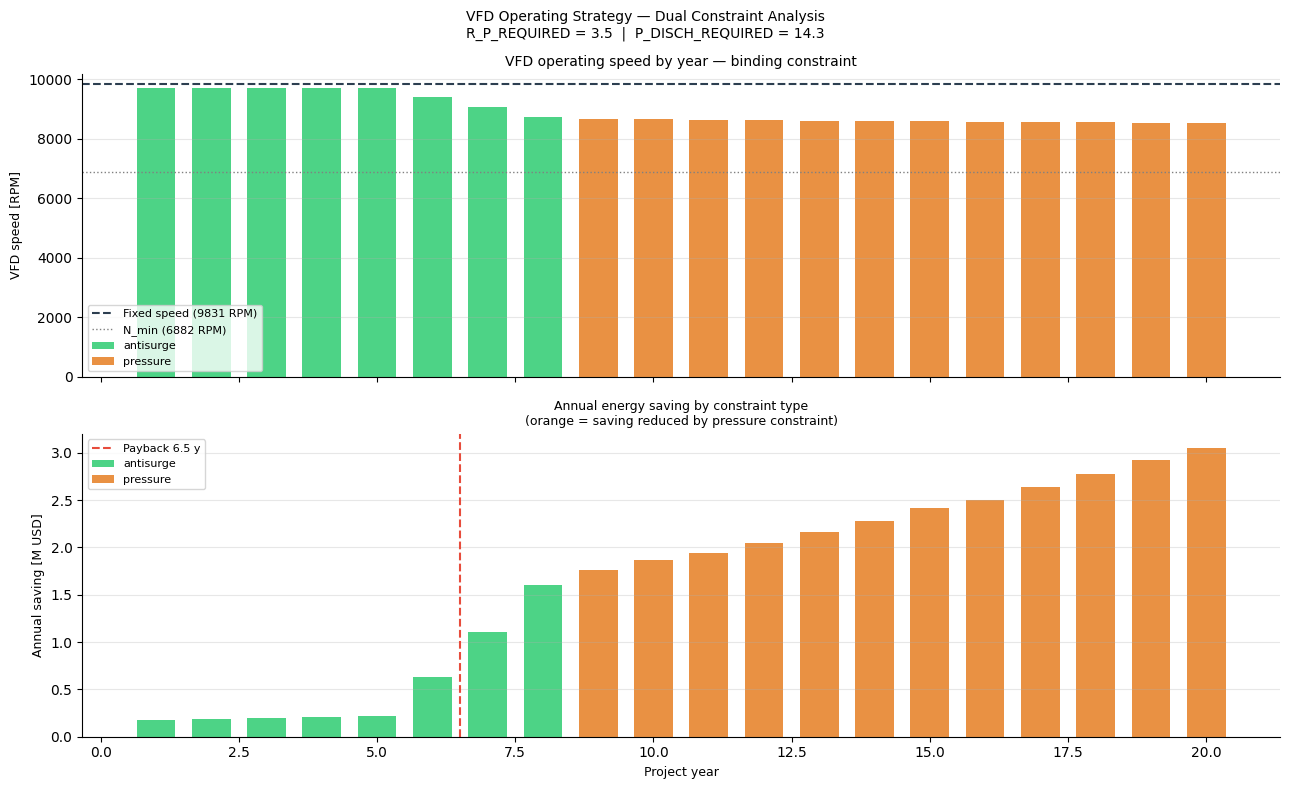

Key insight:
  Green  (antisurge) : VFD at surge-limited speed — maximum saving
  Orange (pressure)  : P_disch forces higher N — partial saving


In [21]:
# ── VFD constraint analysis — N_vfd by year with binding constraint ─────────
BASE_CONSTRAINT_COLORS = {
    "antisurge":     "#2ecc71",
    "pressure":      "#e67e22",
    "N_max+recycle": "#e74c3c",
}

present_constraints = [
    c for c in ["antisurge", "pressure", "N_max+recycle"]
    if (df_fc["constraint"] == c).any()
]
CONSTRAINT_COLORS = {c: BASE_CONSTRAINT_COLORS[c] for c in present_constraints}

rp_str = "None" if R_P_REQUIRED is None else f"{R_P_REQUIRED:g}"
pdisch_str = "None" if P_DISCH_REQUIRED is None else f"{P_DISCH_REQUIRED:.1f}"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle(
    f'VFD Operating Strategy — Dual Constraint Analysis\n'
    f'R_P_REQUIRED = {rp_str}  |  '
    f'P_DISCH_REQUIRED = {pdisch_str}',
    fontsize=10, fontweight='normal'
)
ap = df_fc['year']

# Panel 1 — VFD speed by binding constraint
for constraint, color in CONSTRAINT_COLORS.items():
    mask = df_fc['constraint'] == constraint
    ax1.bar(
        df_fc.loc[mask, 'year'],
        df_fc.loc[mask, 'N_vfd'],
        color=color,
        alpha=0.85,
        width=0.7,
        label=constraint
    )

ax1.axhline(
    N_FIXED,
    color='#2c3e50',
    linewidth=1.5,
    linestyle='--',
    label=f'Fixed speed ({N_FIXED:.0f} RPM)'
)
ax1.axhline(
    SPEEDS[0],
    color='gray',
    linewidth=1,
    linestyle=':',
    label=f'N_min ({SPEEDS[0]:.0f} RPM)'
)

ax1.set_ylabel('VFD speed [RPM]', fontsize=9)
ax1.set_title('VFD operating speed by year — binding constraint', fontsize=10)
ax1.legend(fontsize=8, loc='lower left')
ax1.grid(True, alpha=0.3, axis='y')
ax1.spines[['top', 'right']].set_visible(False)

# Panel 2 — Annual saving by constraint type
for constraint, color in CONSTRAINT_COLORS.items():
    mask = df_fc['constraint'] == constraint
    ax2.bar(
        df_fc.loc[mask, 'year'],
        df_fc.loc[mask, 'saving_USD'] / 1e6,
        color=color,
        alpha=0.85,
        width=0.7,
        label=constraint
    )

if np.isfinite(fc['payback']):
    ax2.axvline(
        fc['payback'],
        color='#e74c3c',
        linewidth=1.5,
        linestyle='--',
        label=f"Payback {fc['payback']:.1f} y"
    )

ax2.set_xlabel('Project year', fontsize=9)
ax2.set_ylabel('Annual saving [M USD]', fontsize=9)
ax2.set_title(
    'Annual energy saving by constraint type\n'
    '(orange = saving reduced by pressure constraint)',
    fontsize=9
)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("Key insight:")
print("  Green  (antisurge) : VFD at surge-limited speed — maximum saving")
if "pressure" in present_constraints:
    print("  Orange (pressure)  : P_disch forces higher N — partial saving")

---
## Summary

### What Python adds to a standalone process simulation workflow

| Capability | DWSIM GUI | Python sandbox |
|---|---|---|
| View one operating point | ✓ | ✓ |
| Sweep full operating envelope | Manual, slow | Instant, automated |
| Model 20-year efficiency degradation | ✗ | ✓ |
| Model gas composition evolution | ✗ | ✓ |
| Quantify Lapina vs rigorous EOS error | ✗ | ✓ |
| Validate against DWSIM programmatically | ✗ | ✓ |
| Compute NPV/IRR with realistic load profile | ✗ | ✓ |
| Calculation engine to develop interactive dashboard | ✗ | ✓ |


### References

This analysis is based on real compressor performance curves, a simplified performance-correction method, a rigorous EOS-based thermodynamic model, and variable-speed compressor control concepts relevant to oil and gas applications.

1. **Petrobras/ccp (Apache 2.0)** - Apache 2.0. https://github.com/petrobras/ccp  
   Real compressor performance curves used as the base dataset for the compressor map, speed-line interpolation, and off-design analysis.

2. **Lapina, R. P. (1982). _How to Use the Performance Curves to Evaluate Behavior of Centrifugal Compressors_.** 
   Reference used for the simplified correction logic relating changes in inlet conditions to discharge pressure and power at fixed speed.

3. **Kurz, R., Mistry, J., Davis, P., & Cole, G. J. (2020). _Application and Control of Variable Speed Centrifugal Compressors in the Oil and Gas Industry_.** 
   Reference used for the physical interpretation of variable-speed operation, surge/recycle control, and the interaction between compressor and system pressure requirements.

5. **`thermo` (Python package)** - MIT. https://github.com/CalebBell/thermo  
   Computational thermodynamics library used for the rigorous EOS-based calculations and comparison against the simplified method.

6. **Campbell Tip of the Month (Nov 2011). _Rigorous vs. shortcut methods for compressor calculations_.**  
   Supporting reference for the distinction between simplified and rigorous thermodynamic approaches.
   http://www.jmcampbell.com/tip-of-the-month/2011/11/compressor-calculations-rigorous-using-equation-of-state-vs-shortcut-method/

7. **Campbell Tip of the Month (Nov 2008). _Effect of molecular weight on compressor performance_.**  
   Supporting reference for interpreting the impact of gas composition and molecular-weight drift on compressor behavior.
   http://www.jmcampbell.com/tip-of-the-month/2008/11/effect-of-gas-molecular-weight-on-centrifugal-compressor-performance/

### Notes
- The present notebook is not a compressor acceptance-test study; it is a **Python-extended techno-economic and operability analysis** built on real curves, changing gas composition, degradation, and VFD control constraints.
